<a href="https://colab.research.google.com/github/Yuqin0708/cat-breed-classifier/blob/main/Now%E3%80%8Ccat_breed_classification%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cat Breed Classification Using Convolutional Neural Networks

Please refer to the [report.pdf](https://gitlab.com/willyfitrahendria/cat-breed-classification-using-cnn/-/blob/master/report.pdf) for a complete analysis and documentation

## 連線 google 雲端硬碟

In [ ]:
#連 google 雲端
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 設定預設路徑
%cd /content/drive/MyDrive/Colab/cat_breed_classification

/content/drive/MyDrive/Colab/cat_breed_classification


## Download the dataset (下載資料集)

Download the Oxford-IIIT Pet dataset.

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

--2024-11-20 02:59:27--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2024-11-20 02:59:29--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  7.29MB/s    in 70s     

2024-11-20 03:00:40 (10.8 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2024-11-20 03:00:40--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

## Extract the downloaded archives

Extract the dataset and place it at 'data' folder.

In [ ]:
!mkdir data
!tar xvzf images.tar.gz -C data
!tar xvzf annotations.tar.gz -C data

串流輸出內容已截斷至最後 5000 行。
annotations/trimaps/._pomeranian_180.png
annotations/trimaps/pomeranian_180.png
annotations/trimaps/._pomeranian_181.png
annotations/trimaps/pomeranian_181.png
annotations/trimaps/._pomeranian_182.png
annotations/trimaps/pomeranian_182.png
annotations/trimaps/._pomeranian_183.png
annotations/trimaps/pomeranian_183.png
annotations/trimaps/._pomeranian_184.png
annotations/trimaps/pomeranian_184.png
annotations/trimaps/._pomeranian_185.png
annotations/trimaps/pomeranian_185.png
annotations/trimaps/._pomeranian_186.png
annotations/trimaps/pomeranian_186.png
annotations/trimaps/._pomeranian_187.png
annotations/trimaps/pomeranian_187.png
annotations/trimaps/._pomeranian_188.png
annotations/trimaps/pomeranian_188.png
annotations/trimaps/._pomeranian_189.png
annotations/trimaps/pomeranian_189.png
annotations/trimaps/._pomeranian_19.png
annotations/trimaps/pomeranian_19.png
annotations/trimaps/._pomeranian_190.png
annotations/trimaps/pomeranian_190.png
annotations/trimaps/.

## Install the modules

Install a specific version of some modules to avoid unexpected behaviours. It may be necessary to restart the kernel after the installation is finished.

In [ ]:
#!pip install torch==1.3.1
#!pip install torchvision==0.4.2
#!pip install numpy==1.15.4
#!pip install pandas==0.24.2
#!pip install matplotlib==3.0.3
#!pip install tqdm==4.38.0
#!pip install sklearn==0.20.3`1
#!pip install seaborn==0.8.1
!pip install torch torchvision pandas matplotlib tqdm scikit-learn
!pip install -U seaborn

## Import the modules

Import the required modules, and check the installed versions.

In [ ]:
import shutil
import os
import re
import copy
import random
import time
import sys
import base64
from glob import glob
from PIL import Image

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sn

import tqdm
from tqdm.notebook import tqdm as tqdm_notebook

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn as nn

import sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import confusion_matrix

os.environ['CUDA_LAUNCH_BLOCKING'] = "1" # to get stacttrace details

print('torch=='+torch.__version__)
print('torchvision=='+torchvision.__version__)
print('numpy=='+np.__version__)
print('pandas=='+pd.__version__)
print('matplotlib=='+mpl.__version__)
print('tqdm=='+tqdm.__version__)
print('sklearn=='+sklearn.__version__)
print('seaborn=='+sn.__version__)

torch==2.5.1+cu121
torchvision==0.20.1+cu121
numpy==1.26.4
pandas==2.2.2
matplotlib==3.8.0
tqdm==4.66.6
sklearn==1.5.2
seaborn==0.13.2


## Filter out dog images

Delete any file which doesn't have cat breed in its name.

In [ ]:
!find data/images/* -type f ! -regex  '\(.*Abyssinian.*\|.*Bengal.*\|.*Birman.*\|.*Bombay.*\|.*British_Shorthair.*\|.*Egyptian_Mau.*\|.*Maine_Coon.*\|.*Persian.*\|.*Ragdoll.*\|.*Russian_Blue.*\|.*Siamese.*\|.*Sphynx.*\)$' -delete

##  Filter out non-jpg images

Delete any file which is not in jpg format.

In [ ]:
!find data/images/* ! -regex '\(.*jpg\)$' -delete

## Load & split dataset

Load the provided metadata of the dataset, and split the images into 'train' & 'test' folder based on the metadata.

### Load list of training data

In [ ]:
# breed id and name mapping
breeds = {
        1 : 'Abyssinian',
        2 : 'Bengal',
        3 : 'Birman',
        4 : 'Bombay',
        5 : 'British_Shorthair',
        6 : 'Egyptian_Mau',
        7 : 'Maine_Coon',
        8 : 'Persian',
        9 : 'Ragdoll',
        10 : 'Russian_Blue',
        11 : 'Siamese',
        12 : 'Sphynx'
    }


In [ ]:
train_df = pd.read_csv('data/annotations/trainval.txt', header=None, sep=' ')
train_df = train_df.iloc[(train_df.iloc[:,2] == 1).values,[0,3]] # filter only cat with file_name and breed columns
train_df = train_df.rename(columns={0 : 'file_name', 3:'breed'})
train_df['breed_name'] = train_df['breed'].map(breeds)
train_df.drop_duplicates(keep=False,inplace=True) # drop duplicates if any

print(len(train_df))
train_df.head(5)

1188


,file_name,breed,breed_name
0,Abyssinian_100,1,Abyssinian
1,Abyssinian_101,1,Abyssinian
2,Abyssinian_102,1,Abyssinian
3,Abyssinian_103,1,Abyssinian
4,Abyssinian_104,1,Abyssinian


### Class distribution of training data

Look into the class distribution to see how balanced or unbalanced the data is.

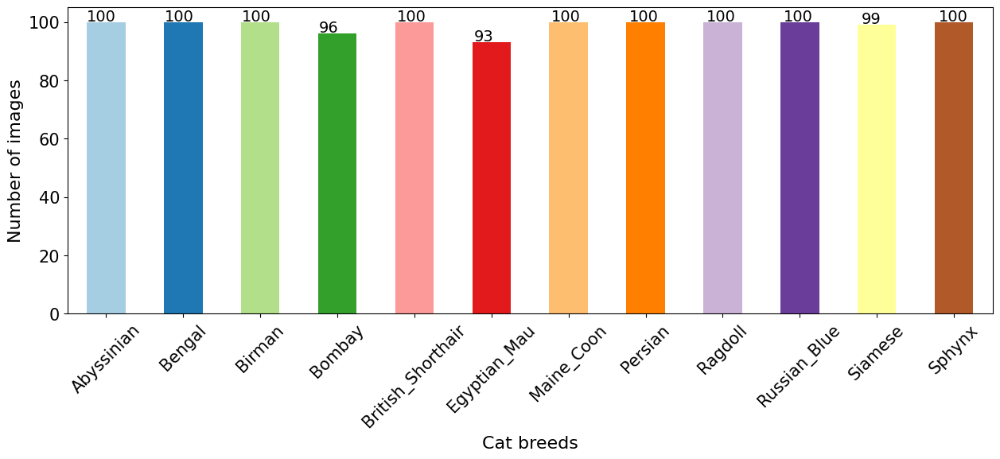

In [ ]:
fig, ax = plt.subplots()

train_df['breed'].value_counts().loc[list(range(1,13))].plot(kind="bar", ax=ax, figsize=(15,5), color=plt.cm.Paired(np.arange(len(train_df))))

ax.set_xticklabels(list(breeds.values()), rotation=45)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Cat breeds', fontsize=16)
ax.set_ylabel('Number of images', fontsize=16)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005),size=14)

#### Load list of testing data

In [ ]:
test_df = pd.read_csv('data/annotations/test.txt', header=None, sep=' ')
test_df = test_df.iloc[(test_df.iloc[:,2] == 1).values,[0,3]] # filter only cat with file_name and breed columns
test_df = test_df.rename(columns={0 : 'file_name', 3:'breed'})
test_df['breed_name'] = test_df['breed'].map(breeds)
test_df.drop_duplicates(keep=False,inplace=True) # drop duplicates if any

print(len(test_df))
test_df.head(5)

1183


,file_name,breed,breed_name
0,Abyssinian_201,1,Abyssinian
1,Abyssinian_202,1,Abyssinian
2,Abyssinian_204,1,Abyssinian
3,Abyssinian_205,1,Abyssinian
4,Abyssinian_206,1,Abyssinian


### Class distribution of testing data

Look into the class distribution to see how balanced or unbalanced the data is.

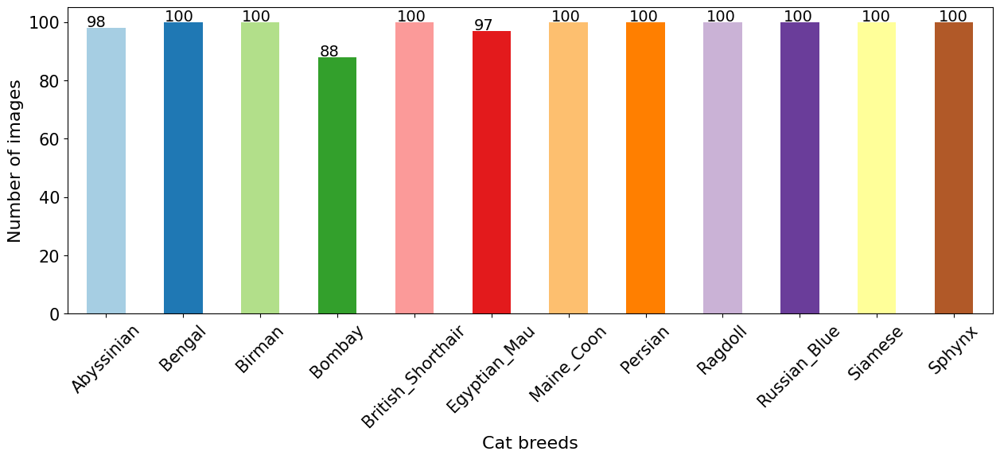

In [ ]:
fig, ax = plt.subplots()

test_df['breed'].value_counts().loc[list(range(1,13))].plot(kind="bar", ax=ax, figsize=(15,5), color=plt.cm.Paired(np.arange(len(test_df))))

ax.set_xticklabels(list(breeds.values()), rotation=45)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Cat breeds', fontsize=16)
ax.set_ylabel('Number of images', fontsize=16)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005),size=14)

### Split into training and testing data

The images are splitted into 'train' and 'test' folders based on the provided metadata.

#### Create the folders

In [ ]:
!mkdir data/train
!mkdir data/test

#### Move the images to the respective folders

In [ ]:
def move_images(source, destination, df):
    for index, row in df.iterrows():
        source_path = source+row['file_name']+'.jpg'
        destination_path = destination+row['breed_name']
        if not os.path.exists(destination_path):
            os.makedirs(destination_path)
        try:
            shutil.move(source_path,destination_path)
        except Exception as e:
            print('error :',e)


move_images('data/images/','data/train/',train_df)
move_images('data/images/','data/test/',test_df)

Just to make sure all the images have been moved, check count of images in both of the training and testing folder:

In [ ]:
!ls data/train/*/* | wc -l
!ls data/test/*/* | wc -l


1188
1183


FYI, there are some images remaining which are not used either for training and testing. We will ignore the images as it is expected (the images were also not used on the previous study in a paper entitled "Cats and Dogs").

In [ ]:
# unused images
!ls data/images/* | wc -l

29


## Set the random seed for reproducibility

In [ ]:
def seed_torch(seed=1029):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    #torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_torch(42)

## Set device to GPU if available

Warning: this notebook was executed & tested using GPU. So please make sure the GPU is available to avoid unexpected error.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Utils functions

The functions which are used across model building and evaluation.

In [ ]:
def accuracy(output, target, topk=(1,)):
    """Computes the accuracy over the k top predictions for the specified values of k

    source: https://github.com/pytorch/examples/blob/master/imagenet/main.py"""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))

        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size))
        return res

def save_model_state(model, path):
    torch.save(model.state_dict(), path)

def load_model_state(model, path):
    model.load_state_dict(torch.load(path))
    model = model.to(device)
    return model

def get_cv_result_per_epoch(history):
    """Computes the accuracy & loss of cross validation per epoch"""
    cv_results = []

    for i,history_per_fold in enumerate(history):
        cv_result_per_epoch = []
        for j in range(len(history_per_fold[0])):
            cv_train_acc = 0.0
            cv_train_loss = 0.0
            cv_valid_acc = 0.0
            cv_valid_loss = 0.0
            cv_train_data_size = 0
            cv_valid_data_size = 0

            for k,history_per_epoch in enumerate(history_per_fold):
                cv_train_acc += history_per_epoch[j]['avg_train_acc']*history_per_epoch[j]['train_data_size']
                cv_train_loss += history_per_epoch[j]['avg_train_loss']*history_per_epoch[j]['train_data_size']
                cv_valid_acc += history_per_epoch[j]['avg_valid_acc']*history_per_epoch[j]['valid_data_size']
                cv_valid_loss += history_per_epoch[j]['avg_valid_loss']*history_per_epoch[j]['valid_data_size']
                cv_train_data_size += history_per_epoch[j]['train_data_size']
                cv_valid_data_size += history_per_epoch[j]['valid_data_size']

            cv_result_per_epoch.append({
                'params' : history_per_epoch[0]['params'],
                'epoch' : j+1,
                'cv_train_acc' : cv_train_acc/float(cv_train_data_size),
                'cv_train_loss' : cv_train_loss/float(cv_train_data_size),
                'cv_valid_acc' : cv_valid_acc/float(cv_valid_data_size),
                'cv_valid_loss' : cv_valid_loss/float(cv_valid_data_size)
            })
        cv_results.append(cv_result_per_epoch)

    return cv_results

def get_best_cv_result(cv_history):
    """Return the best cross validation result with respect to the validation loss."""

    # generate cross validation results per epoch
    cv_results = get_cv_result_per_epoch(cv_history)

    best_cv_result = {}
    for cv_result_per_epoch in cv_results:
        for cv_result in cv_result_per_epoch:
            if not best_cv_result or cv_result['cv_valid_loss'] < best_cv_result['cv_valid_loss']:
                best_cv_result = cv_result

    return best_cv_result


def plot_cv_result(cv_history):
    """Plot the cross validation accuracy and loss for each of the tuned hyperparameters".
    It is necessary to update this function if the number of hyperparameter combinations
    being tuned are not equal to 4"""

    # TODO make this function more dynamic wrt the number of hyperparameter combinations

    # generate cross validation results per epoch
    cv_results = get_cv_result_per_epoch(cv_history)

    plot_params = []
    plot_valid_loss = []
    plot_valid_acc = []

    for cv_result in cv_results:
        plot_params.append(cv_result[0]['params'])
        plot_valid_loss.append([val['cv_valid_loss'] for val in cv_result ])
        plot_valid_acc.append([val['cv_valid_acc'] for val in cv_result ])

    x = np.arange(1,len(plot_valid_loss[0])+1)

    print('\n------------ Validation loss per epoch ------------')

    for i in range(len(plot_valid_loss)):
        plt.plot(x,plot_valid_loss[i],label=plot_params[i])
    plt.legend(loc="upper right")
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.show()

    fig, ax = plt.subplots(2, 2,figsize=(15,9))

    ax[0,0].plot(x,plot_valid_loss[0],label=plot_params[0])
    ax[0,0].plot(x,plot_valid_loss[1],label=plot_params[1])
    ax[0,0].legend(loc="upper right")
    ax[0,0].set_ylabel('loss')
    ax[0,0].set_xlabel('epochs')

    ax[0,1].plot(x,plot_valid_loss[2],label=plot_params[2])
    ax[0,1].plot(x,plot_valid_loss[3],label=plot_params[3])
    ax[0,1].legend(loc="upper right")
    ax[0,1].set_ylabel('loss')
    ax[0,1].set_xlabel('epochs')

    ax[1,0].plot(x,plot_valid_loss[0],label=plot_params[0])
    ax[1,0].plot(x,plot_valid_loss[2],label=plot_params[2])
    ax[1,0].legend(loc="upper right")
    ax[1,0].set_ylabel('loss')
    ax[1,0].set_xlabel('epochs')

    ax[1,1].plot(x,plot_valid_loss[1],label=plot_params[1])
    ax[1,1].plot(x,plot_valid_loss[3],label=plot_params[3])
    ax[1,1].legend(loc="upper right")
    ax[1,1].set_ylabel('loss')
    ax[1,1].set_xlabel('epochs')

    plt.show()

    print('\n------------ Validation accuracy per epoch at ------------')

    for i in range(len(plot_valid_acc)):
        plt.plot(x,plot_valid_acc[i],label=plot_params[i])
    plt.legend(loc="lower right")
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.show()

    fig, ax = plt.subplots(2, 2,figsize=(15,9))

    ax[0,0].plot(x,plot_valid_acc[0],label=plot_params[0])
    ax[0,0].plot(x,plot_valid_acc[1],label=plot_params[1])
    ax[0,0].legend(loc="lower right")
    ax[0,0].set_ylabel('accuracy')
    ax[0,0].set_xlabel('epochs')

    ax[0,1].plot(x,plot_valid_acc[2],label=plot_params[2])
    ax[0,1].plot(x,plot_valid_acc[3],label=plot_params[3])
    ax[0,1].legend(loc="lower right")
    ax[0,1].set_ylabel('accuracy')
    ax[0,1].set_xlabel('epochs')

    ax[1,0].plot(x,plot_valid_acc[0],label=plot_params[0])
    ax[1,0].plot(x,plot_valid_acc[2],label=plot_params[2])
    ax[1,0].legend(loc="lower right")
    ax[1,0].set_ylabel('accuracy')
    ax[1,0].set_xlabel('epochs')

    ax[1,1].plot(x,plot_valid_acc[1],label=plot_params[1])
    ax[1,1].plot(x,plot_valid_acc[3],label=plot_params[3])
    ax[1,1].legend(loc="lower right")
    ax[1,1].set_ylabel('accuracy')
    ax[1,1].set_xlabel('epochs')

    plt.show()

def plot_train_result(train_history):
    """Plot the training loss and the training accuracy of the retrained model"""
    plot_params = []
    plot_train_loss = []
    plot_train_acc = []

    x = np.arange(1, len(train_history)+1)

    for hist in train_history:
        plot_train_loss.append(hist['avg_train_loss'])
        plot_train_acc.append(hist['avg_train_acc']*100)

    plt.plot(x,plot_train_loss)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title('Training loss')
    plt.show()

    plt.plot(x,plot_train_acc)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.title('Training accuracy')
    plt.show()

## Load and transform images

Load the images, and transform the images in order to use pretrained model for transfer learning.

In [ ]:
# the expected normalization by the pretrained model
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# transforms for the images (without augmentation)
# here, both train and test have the same transformation
image_transforms = {
    'train': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        normalize
    ]),
    'test': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        normalize
    ])
}

# transforms with augmentation on the training data
augmented_image_transforms = {
    'train': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        normalize
    ]),
    'test': transforms.Compose([
        transforms.Resize(size=256),
        transforms.CenterCrop(size=224),
        transforms.ToTensor(),
        normalize
    ])
}

# train and test directory paths
train_directory = 'data/train'
test_directory = 'data/test'

# load data from folders
data = {
    'train': datasets.ImageFolder(root=train_directory), # transforms applied in the cross validation later
    'test': datasets.ImageFolder(root=test_directory, transform=image_transforms['test'])
}

# mapping class index to class name
idx_to_class = {val: key for key, val in data['test'].class_to_idx.items()}

# needed for StratifiedKFold
train_images = [d[0] for d in tqdm_notebook(data['train'], desc='train_images')]
train_labels = [d[1] for d in tqdm_notebook(data['train'], desc='train_labels')]

train_images:   0%|          | 0/1188 [00:00<?, ?it/s]

train_labels:   0%|          | 0/1188 [00:00<?, ?it/s]

### Visualize sample of transformed image

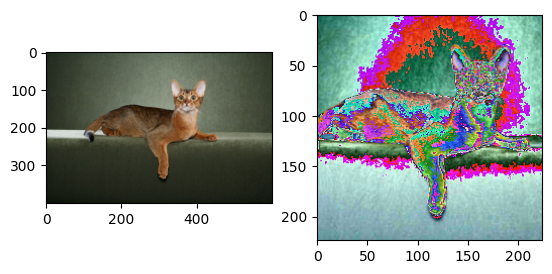

In [ ]:
# resized, cropped, normalized image

to_pil = torchvision.transforms.ToPILImage()

ori_img = data['train'][0][0]
trans_img = to_pil(image_transforms['train'](ori_img))

f, axarr = plt.subplots(1,2)
axarr[0].imshow(ori_img)
axarr[1].imshow(trans_img)

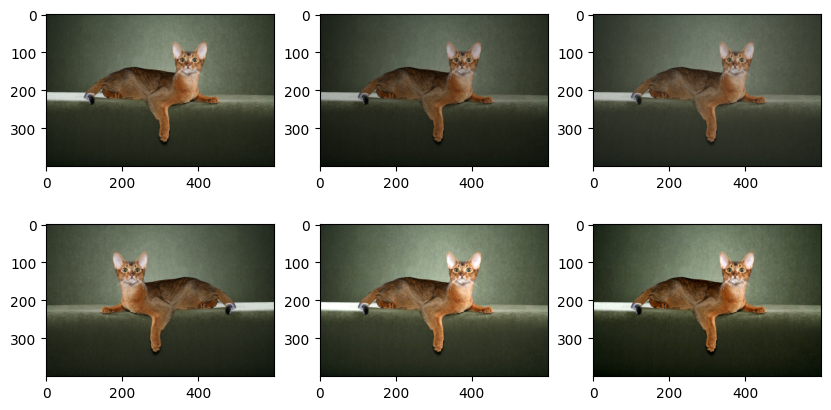

In [ ]:
# flipped, modified brightness, modified contrast

horizontal_flip = transforms.RandomHorizontalFlip(p=1)
darken = transforms.ColorJitter(brightness=(0.8,0.8))
brighten = transforms.ColorJitter(brightness=(1.2,1.2))
dec_contrast = transforms.ColorJitter(contrast=(0.8,0.8)) # decrease contrast
inc_contrast = transforms.ColorJitter(contrast=(1.2,1.2)) # increase contrast

ori_img = data['train'][0][0]
flip_img = horizontal_flip(ori_img)
dark_img = darken(ori_img)
bright_img = brighten(ori_img)
dec_con_img = dec_contrast(ori_img)
inc_con_img = inc_contrast(ori_img)

f, axarr = plt.subplots(2,3, figsize=(10,5))
axarr[0,0].imshow(ori_img)
axarr[0,1].imshow(dark_img)
axarr[0,2].imshow(dec_con_img)
axarr[1,0].imshow(flip_img)
axarr[1,1].imshow(bright_img)
axarr[1,2].imshow(inc_con_img)

## Grid Search & Cross Validation function

In [ ]:
def grid_search_cv(model, k_fold=5, epochs=10, hyperparameters={'batch_size':[32,64],'learning_rate' : [1e-03, 1e-04]},transforms=image_transforms):
    """Performs hyperparameter tuning with grid search, and evaluates the models using cross validation"""

    # split the data into k folds, for cross validation
    kFold = StratifiedKFold(n_splits = k_fold, shuffle = True, random_state = 42)

    # for grid search
    param_grid = ParameterGrid(hyperparameters)

    # loss function
    loss_criterion = nn.NLLLoss()

    # to store the results for plotting
    history_per_param = []

    for i_params, params in enumerate(param_grid):
        hyperparameter_start = time.time()

        bs = params['batch_size']
        lr = params['learning_rate']
        print('Hyperparameters {}/{} > bs: {} - lr: {}'.format(i_params+1, len(list(param_grid)), bs, lr))

        cv_train_loss = 0.0
        cv_valid_loss = 0.0
        cv_train_acc = 0.0
        cv_valid_acc = 0.0

        history_per_fold = []

        for i_fold, (train_idx, valid_idx) in enumerate(kFold.split(train_images, train_labels)):
            fold_start = time.time()

            # reset the state of the model
            model.load_state_dict(init_state)

            # recreate the Adam optimizer
            optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,model.parameters()), lr=lr)

            train_data_size = len(train_idx)
            valid_data_size = len(valid_idx)

            print('Fold {}/{} > training data size: {} - validation data size: {}'.format(i_fold+1,k_fold,train_data_size,valid_data_size))

            # apply the transforms, and create list of tuple image and label
            train_ds = [(transforms['train'](train_images[i]), train_labels[i]) for i in train_idx]
            valid_ds = [(transforms['test'](train_images[i]), train_labels[i]) for i in valid_idx]

            # data loader for mini-batch iteration
            train_data_loader = torch.utils.data.DataLoader(train_ds, batch_size=bs, shuffle=True)
            valid_data_loader = torch.utils.data.DataLoader(valid_ds, batch_size=bs, shuffle=True)

            history_per_epoch = []

            for epoch in range(epochs):
                epoch_start = time.time()
                print("\nEpoch {}/{}".format(epoch+1, epochs))

                # set to training mode
                model.train()

                # loss and accuracy within the epoch
                train_loss = 0.0
                train_acc = 0.0
                valid_loss = 0.0
                valid_acc = 0.0

                for i, (inputs, labels) in enumerate(train_data_loader):

                    # put inputs and labels to GPU if available
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # clean existing gradients
                    optimizer.zero_grad()

                    # forward pass
                    outputs = model(inputs)

                    # compute loss
                    loss = loss_criterion(outputs, labels)

                    # backpropagate the gradients
                    loss.backward()

                    # update the parameters
                    optimizer.step()

                    # compute the total loss in the batch, and add to train_loss
                    train_loss += loss.item() * inputs.size(0)

                    # compute the accuracy
                    ret, predictions = torch.max(outputs.data, 1)
                    correct_counts = predictions.eq(labels.data.view_as(predictions))
                    acc = torch.mean(correct_counts.type(torch.FloatTensor))

                    # compute total accuracy in the batch and add to train_acc
                    train_acc += acc.item() * inputs.size(0)

                    print("Training Batch {:03d} > loss: {} - acc: {}".format(i, loss.item(), acc.item()))

                # validation
                with torch.no_grad():

                    # set to evaluation mode
                    model.eval()

                    for j, (inputs, labels) in enumerate(valid_data_loader):

                        # put inputs and labels to GPU if available
                        inputs = inputs.to(device)
                        labels = labels.to(device)

                        # forward pass
                        outputs = model(inputs)

                        # compute loss
                        loss = loss_criterion(outputs, labels)

                        # compute the total loss in the batch, and add to valid_loss
                        valid_loss += loss.item() * inputs.size(0)

                        # calculate validation accuracy
                        ret, predictions = torch.max(outputs.data, 1)
                        correct_counts = predictions.eq(labels.data.view_as(predictions))
                        acc = torch.mean(correct_counts.type(torch.FloatTensor))

                        # compute total accuracy in the batch and add valid_acc
                        valid_acc += acc.item() * inputs.size(0)

                        print("Validation Batch {:03d} > valid_loss: {}, valid_acc: {}".format(j, loss.item(), acc.item()))

                # compute average training loss and training accuracy
                avg_train_loss = train_loss/float(train_data_size)
                avg_train_acc = train_acc/float(train_data_size)

                # compute average training loss and training accuracy
                avg_valid_loss = valid_loss/float(valid_data_size)
                avg_valid_acc = valid_acc/float(valid_data_size)

                history_per_epoch.append({
                                'params' : params,
                                'avg_train_loss': avg_train_loss,
                                'avg_valid_loss': avg_valid_loss,
                                'avg_train_acc': avg_train_acc,
                                'avg_valid_acc':avg_valid_acc,
                                'train_data_size':train_data_size,
                                'valid_data_size':valid_data_size
                                })

                epoch_end = time.time()

                print("End Epoch {}/{} > loss: {} - acc: {}% - valid_loss: {} - valid_acc: {}% - Time: {:.4f}s".format(epoch+1, epochs, avg_train_loss, avg_train_acc*100, avg_valid_loss, avg_valid_acc*100, epoch_end-epoch_start))

            history_per_fold.append(history_per_epoch)

            cv_train_loss += avg_train_loss
            cv_valid_loss += avg_valid_loss
            cv_train_acc += avg_train_acc
            cv_valid_acc += avg_valid_acc

            fold_end = time.time()
            print("End Fold {}/{} > time: {:.4f}s\n".format(i_fold+1, k_fold, fold_end - fold_start))

        history_per_param.append(history_per_fold)

        hyperparameter_end = time.time()

        print('End Hyperparameters {}/{} > bs: {} - lr: {} - time: {:.4f}s'.format(i_params+1, len(list(param_grid)), bs, lr, hyperparameter_end - hyperparameter_start))
        print('                       > loss: {} - acc: {}% - valid_loss: {} - valid_acc: {}% - Time: {:.4f}s\n'.format(cv_train_loss/k_fold, (cv_train_acc/k_fold)*100, cv_valid_loss/k_fold, (cv_valid_acc/k_fold)*100, hyperparameter_end-hyperparameter_start))
    return history_per_param

## Simple CNN (without transfer Learning)

### Build the network

In [ ]:
class Flatten(torch.nn.Module):
    '''to flatten convolutional layer outputs'''
    def forward(self, x):
        batch_size = x.shape[0]
        return x.view(batch_size, -1)

# build the simple CNN
simpleCNN = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5, stride=1, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    Flatten(),
    nn.Dropout(p=0.5),
    nn.Linear(64*112*112, 12),
    nn.LogSoftmax(dim=1) # For using NLLLoss()
)

# move the model to a device
simpleCNN = simpleCNN.to(device)

# copy initial state, used for retraining later
init_state = copy.deepcopy(simpleCNN.state_dict())

### Perfom grid search & cross validation

In [ ]:
cv_history = grid_search_cv(simpleCNN, k_fold=5, epochs=50, hyperparameters={'batch_size':[32,64],'learning_rate' : [1e-03, 1e-04]})

串流輸出內容已截斷至最後 5000 行。
Training Batch 009 > loss: 0.013588545843958855 - acc: 1.0
Training Batch 010 > loss: 0.016319099813699722 - acc: 1.0
Training Batch 011 > loss: 0.015275964513421059 - acc: 1.0
Training Batch 012 > loss: 0.015829715877771378 - acc: 1.0
Training Batch 013 > loss: 0.014535514637827873 - acc: 1.0
Training Batch 014 > loss: 0.013556886464357376 - acc: 1.0
Validation Batch 000 > valid_loss: 2.230163335800171, valid_acc: 0.390625
Validation Batch 001 > valid_loss: 2.765745162963867, valid_acc: 0.265625
Validation Batch 002 > valid_loss: 3.0291779041290283, valid_acc: 0.203125
Validation Batch 003 > valid_loss: 3.03987193107605, valid_acc: 0.239130437374115
End Epoch 24/50 > loss: 0.0151580038117735 - acc: 100.0% - valid_loss: 2.745544700061574 - valid_acc: 27.731092487062725% - Time: 1.2961s

Epoch 25/50
Training Batch 000 > loss: 0.016409767791628838 - acc: 1.0
Training Batch 001 > loss: 0.01096474751830101 - acc: 1.0
Training Batch 002 > loss: 0.015059307217597961 - ac

###  Result of grid search & cross validation


------------ Best cross validation result ------------
{'params': {'batch_size': 32, 'learning_rate': 0.0001}, 'epoch': 9, 'cv_train_acc': 1.0, 'cv_train_loss': 0.03396575914512417, 'cv_valid_acc': 0.28535353579254263, 'cv_valid_loss': 2.7308554958414146}

------------ Validation loss per epoch ------------


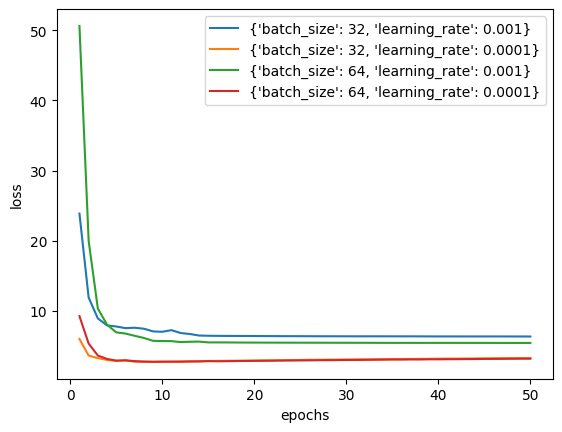

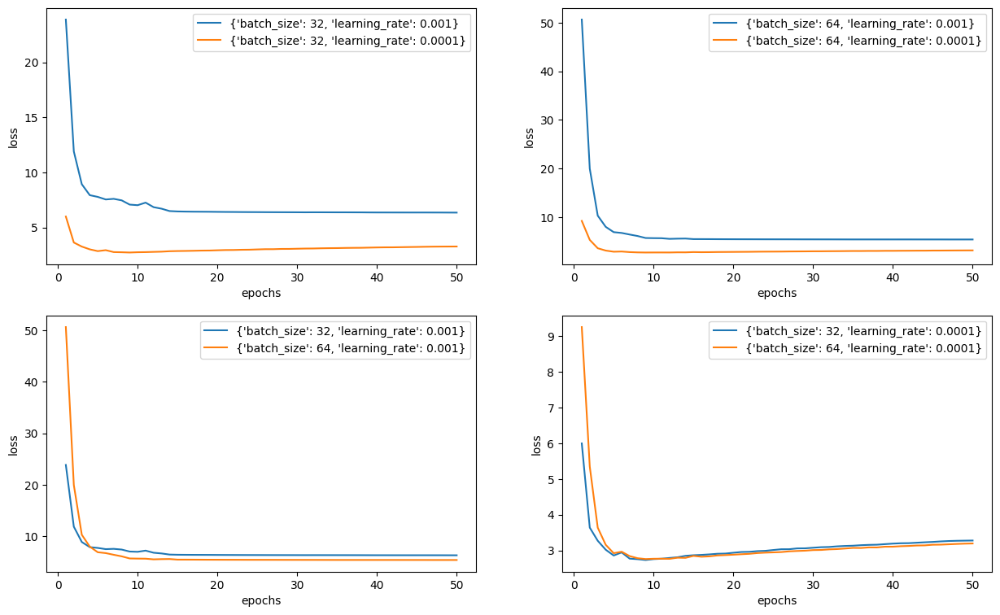


------------ Validation accuracy per epoch at ------------


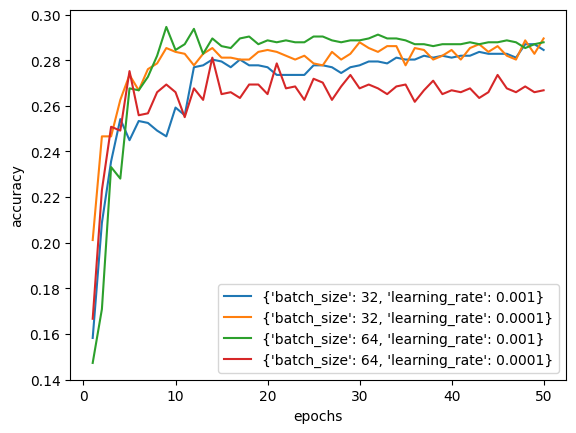

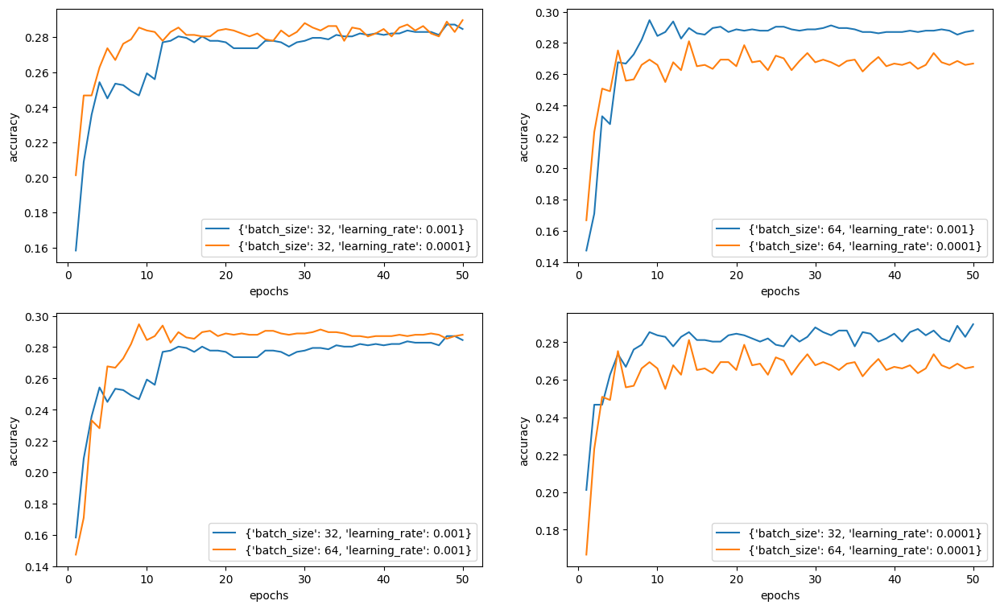

In [ ]:
# get the best cross validation result
best_cv_result = get_best_cv_result(cv_history)

print('\n------------ Best cross validation result ------------')
print(best_cv_result)

plot_cv_result(cv_history)

### Training on full training data

The final model is retrained on full training data using the best parameters.

In [ ]:
simpleCNN, train_history = train(
  simpleCNN,
  best_cv_result['epoch'],
  best_cv_result['params']['batch_size'],
  best_cv_result['params']['learning_rate'],
  init_state
)

Training > training data size: 1188

Epoch 1/9


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 1/9 > loss: 7.8330 - acc: 19.3603% - Time: 11.8421s

Epoch 2/9


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 2/9 > loss: 2.9782 - acc: 40.9933% - Time: 11.2078s

Epoch 3/9


...

End Epoch 7/9 > loss: 0.0894 - acc: 99.4949% - Time: 11.4198s

Epoch 8/9


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 8/9 > loss: 0.0548 - acc: 100.0000% - Time: 11.3289s

Epoch 9/9


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 9/9 > loss: 0.0422 - acc: 100.0000% - Time: 11.4116s
End Train > time: 105.4273s



## ResNet-50 (Pretrained)
ResNet-50（預訓練模型）

### Build the network
建立網路

In [ ]:
# 使用 torchvision 提供的 ResNet-50 預訓練模型
# pretrained=True 表示加載已在 ImageNet 數據集上訓練好的權重
resnet50 = torchvision.models.resnet50(pretrained=True)

# 凍結模型的參數
# Transfer Learning 的常見策略是凍結預訓練模型的大部分層，僅修改最後幾層
for param in resnet50.parameters():
    param.requires_grad = False  # 設定 requires_grad=False，防止更新這些參數

# 獲取 ResNet-50 最後全連接層 (Fully Connected Layer) 的輸入特徵數量
fc_inputs = resnet50.fc.in_features  # ResNet-50 的輸出層的輸入節點數

# 替換 ResNet-50 的最後全連接層以適應新的分類問題
# 假設我們的目標是將影像分為 12 個類別
resnet50.fc = nn.Sequential(
    nn.Linear(fc_inputs, 12),   # 定義輸出層，將輸入特徵數映射到 12 個類別
    nn.LogSoftmax(dim=1)       # 使用 LogSoftmax 層，適合與 NLLLoss 損失函數搭配使用
)

# 將模型移動到指定的設備上運行（例如 CPU 或 GPU）
# device 是預先定義的變數，通常為 torch.device("cuda") 或 torch.device("cpu")
resnet50 = resnet50.to(device)

# 複製模型的初始狀態
# 使用 copy.deepcopy 將模型的參數（state_dict）深度複製一份
# 這樣可以保留模型的初始權重，便於後續重新訓練或實驗時恢復到原始狀態
init_state = copy.deepcopy(resnet50.state_dict())


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


### Perform grid search & cross validation

In [ ]:
# 執行網格搜尋與交叉驗證來尋找最佳超參數組合
cv_history = grid_search_cv(
    resnet50,                      # 模型：這裡使用修改過的 ResNet-50 模型
    k_fold=5,                      # 5 折交叉驗證：將資料集分為 5 等分，輪流作為訓練集與驗證集
    epochs=50,                     # 每組超參數的訓練輪數（epoch）：最多進行 50 輪訓練
    hyperparameters={              # 定義要搜尋的超參數範圍
        'batch_size': [32, 64],    # 搜尋批量大小（batch size）：可能值為 32 和 64
        'learning_rate': [1e-03, 1e-04]  # 搜尋學習率（learning rate）：可能值為 0.001 和 0.0001
    }
)


串流輸出內容已截斷至最後 5000 行。
Training Batch 009 > loss: 0.6686322689056396 - acc: 0.921875
Training Batch 010 > loss: 0.5592846274375916 - acc: 0.953125
Training Batch 011 > loss: 0.5208992958068848 - acc: 0.96875
Training Batch 012 > loss: 0.643807053565979 - acc: 0.875
Training Batch 013 > loss: 0.5440738201141357 - acc: 0.953125
Training Batch 014 > loss: 0.6449893712997437 - acc: 0.9074074029922485
Validation Batch 000 > valid_loss: 0.5867159366607666, valid_acc: 0.921875
Validation Batch 001 > valid_loss: 0.7546391487121582, valid_acc: 0.8125
Validation Batch 002 > valid_loss: 0.6373344659805298, valid_acc: 0.875
Validation Batch 003 > valid_loss: 0.707255482673645, valid_acc: 0.8478260636329651
End Epoch 24/50 > loss: 0.6171054320586356 - acc: 92.84210523806121% - valid_loss: 0.6687810230655831 - valid_acc: 86.55462139794807% - Time: 2.4032s

Epoch 25/50
Training Batch 000 > loss: 0.618228554725647 - acc: 0.953125
Training Batch 001 > loss: 0.6189815402030945 - acc: 0.9375
Training Batch

###  Result of grid search & cross validation
網格搜尋與交叉驗證的結果


------------ Best cross validation result ------------
{'params': {'batch_size': 32, 'learning_rate': 0.001}, 'epoch': 27, 'cv_train_acc': 0.9890572390572391, 'cv_train_loss': 0.07113374600121093, 'cv_valid_acc': 0.905723904820805, 'cv_valid_loss': 0.26826179807736017}

------------ Validation loss per epoch ------------


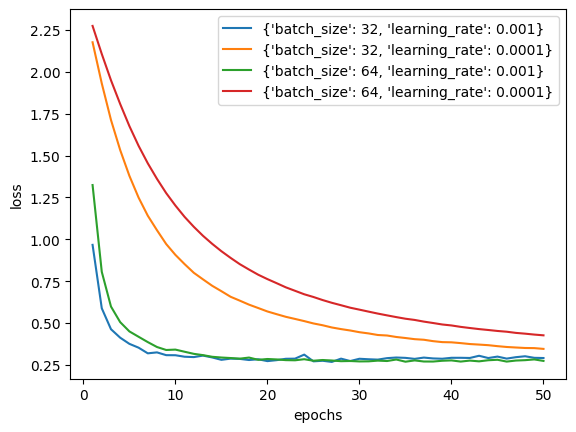

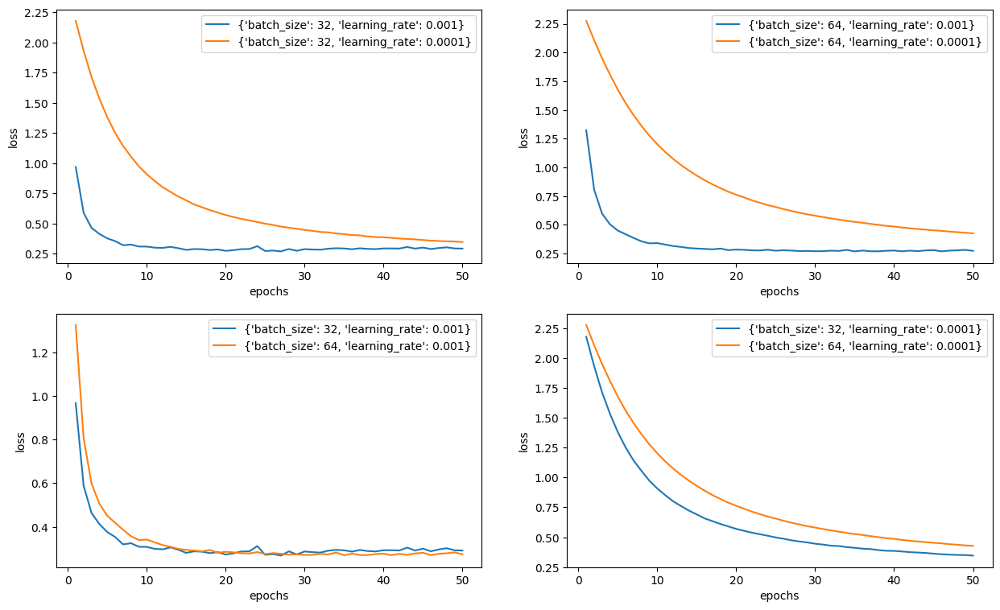


------------ Validation accuracy per epoch at ------------


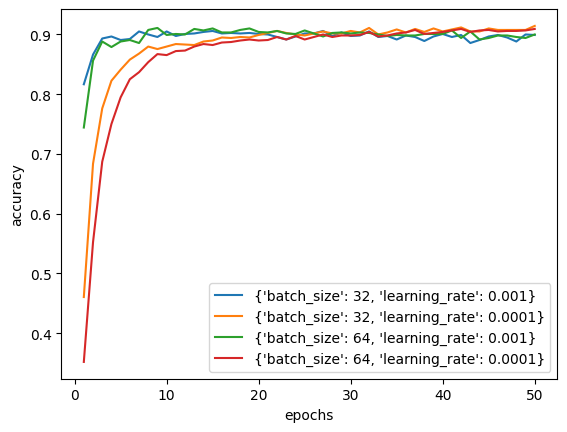

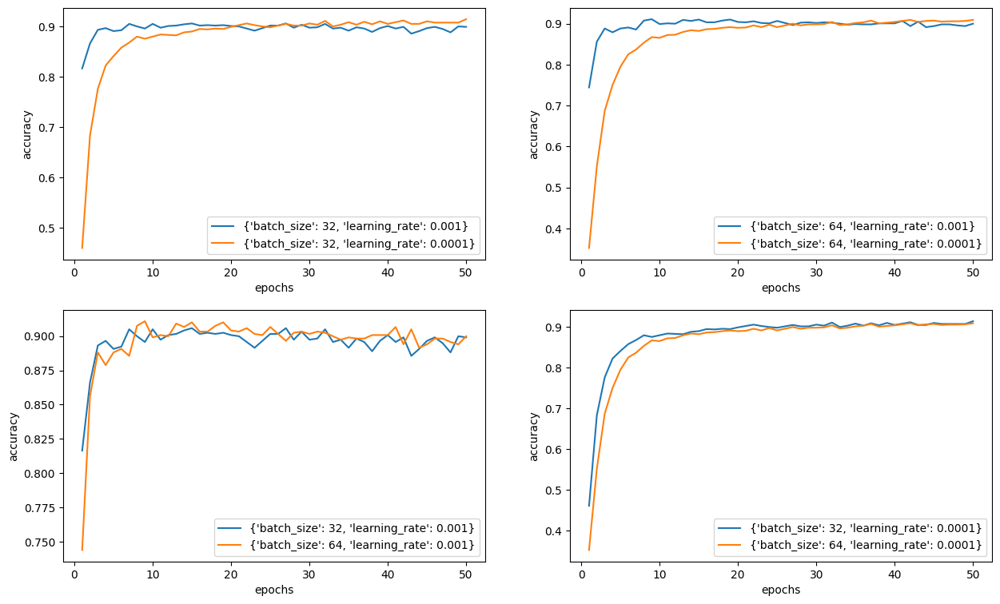

In [ ]:
# 從交叉驗證的歷史結果中提取最佳結果
# `get_best_cv_result` 是一個自定義函數，從網格搜尋與交叉驗證記錄中提取性能最佳的參數組合及對應結果
best_cv_result = get_best_cv_result(cv_history)

# 輸出分隔線，用於清晰展示最佳交叉驗證結果
print('\n------------ Best cross validation result ------------')

# 打印最佳的交叉驗證結果，方便用戶了解最佳的超參數組合和模型性能
print(best_cv_result)

# 視覺化交叉驗證結果
# `plot_cv_result` 是一個自定義函數，用於繪製圖表，顯示不同超參數組合的效能比較（如準確率或損失值）
plot_cv_result(cv_history)


### Training on full training data
在完整的訓練資料上進行訓練

The final model is retrained on full training data using the best parameters.
最終模型使用最佳參數在完整的訓練資料上重新訓練。

In [ ]:
# 使用最佳參數在完整訓練資料上重新訓練最終模型
resnet50, train_history = train(
    resnet50,                          # 模型：這裡傳入經過調整的 ResNet-50 模型
    best_cv_result['epoch'],           # 使用交叉驗證中找到的最佳訓練輪數（epoch），避免過度或不足訓練
    best_cv_result['params']['batch_size'],  # 使用最佳批量大小（batch size），提高訓練效率和性能
    best_cv_result['params']['learning_rate'],  # 使用最佳學習率（learning rate），確保模型快速且穩定地收斂
    init_state                         # 傳入模型的初始狀態（state_dict），確保重新訓練的起點一致
)


Training > training data size: 1188

Epoch 1/27


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 1/27 > loss: 1.6173 - acc: 51.6835% - Time: 11.6333s

Epoch 2/27


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 2/27 > loss: 0.6635 - acc: 86.3636% - Time: 11.4443s

Epoch 3/27


...

End Epoch 25/27 > loss: 0.0755 - acc: 98.8215% - Time: 11.4997s

Epoch 26/27


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 26/27 > loss: 0.0914 - acc: 97.9798% - Time: 11.4761s

Epoch 27/27


Training:   0%|          | 0/38 [00:00<?, ?it/s]

End Epoch 27/27 > loss: 0.1397 - acc: 95.6229% - Time: 11.5176s
End Train > time: 310.6449s



### Result of training
訓練結果

loss : 0.1396955067059809
acc : 95.62289562289563


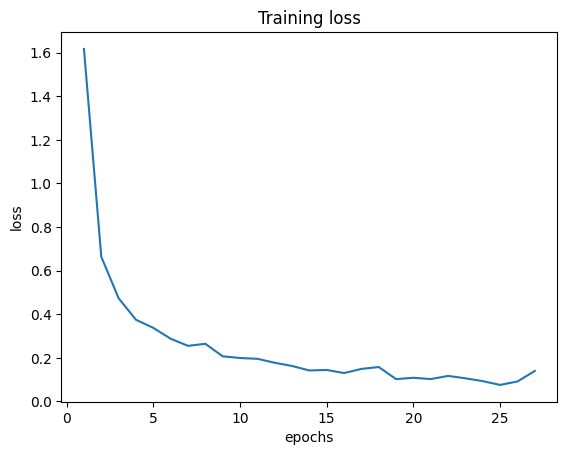

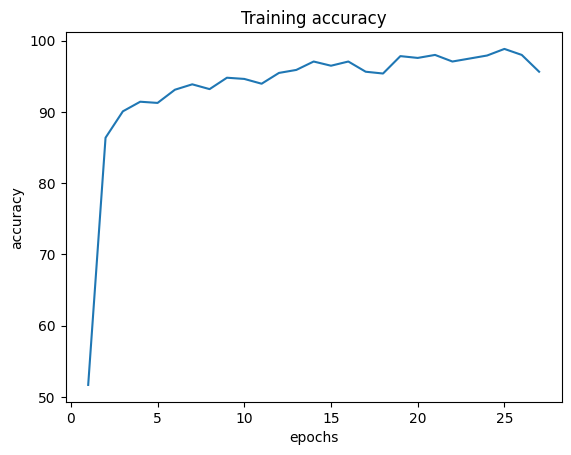

In [ ]:
# 打印訓練過程的最終損失值（loss）
# `train_history` 是一個列表，記錄了每個 epoch 的訓練歷史
# `train_history[-1]` 表示取最後一個 epoch 的記錄（即最終的訓練結果）
print('loss :', train_history[-1]['avg_train_loss'])
# `avg_train_loss` 是平均訓練損失值，表示模型在訓練資料上的預測誤差大小

# 打印訓練過程的最終準確率（accuracy），並將結果轉換為百分比形式
print('acc :', train_history[-1]['avg_train_acc'] * 100)
# `avg_train_acc` 是平均訓練準確率，表示模型在訓練資料上正確分類的比例
# 乘以 100 是為了將準確率轉換為百分比，方便閱讀

# 視覺化訓練結果
# `plot_train_result` 是一個自定義函數，用於繪製圖表展示訓練過程中的損失值和準確率變化
plot_train_result(train_history)


### Testing
測試

In [ ]:
# 測試模型性能，計算損失、準確率、混淆矩陣和 Top-3 準確率
results = test(
    resnet50,              # 測試的模型，這裡是已訓練好的 ResNet-50 模型
    calc_top3_acc=True     # 啟用 Top-3 準確率計算，用於評估模型在前三個預測中的表現
)

# 從測試結果中提取損失值（Loss）
loss = results[0]
# `results[0]` 是測試的平均損失值，表示模型在測試資料上的預測與真實標籤之間的誤差大小

# 從測試結果中提取準確率（Accuracy）
acc = results[1]
# `results[1]` 是測試準確率，表示模型在測試資料上正確分類的比例

# 從測試結果中提取混淆矩陣（Confusion Matrix）
cm = results[2]
# `results[2]` 是混淆矩陣，用於顯示模型對每個類別的預測正確與錯誤分佈
# 混淆矩陣是一個矩陣，其中：
# - 行（Row）表示實際類別
# - 列（Column）表示模型預測的類別

# 從測試結果中提取 Top-3 準確率（Top-3 Accuracy）
top3_acc = results[3]
# `results[3]` 是 Top-3 準確率，表示模型在測試資料上，真實標籤是否包含在前三個預測結果中


Test data size : 1183 



Testing:   0%|          | 0/37 [00:00<?, ?it/s]


Result > loss: 0.4167 - acc: 87.5740% - time: 10.9653s


Result > top3_acc: 97.8022% 



### Result of testing
測試結果

loss : 0.41672725629121293
acc : 87.57396442146495
average fscore: 87.63582904227296
top3 acc : 97.8021978021978

------------ Confusion Matrix ------------


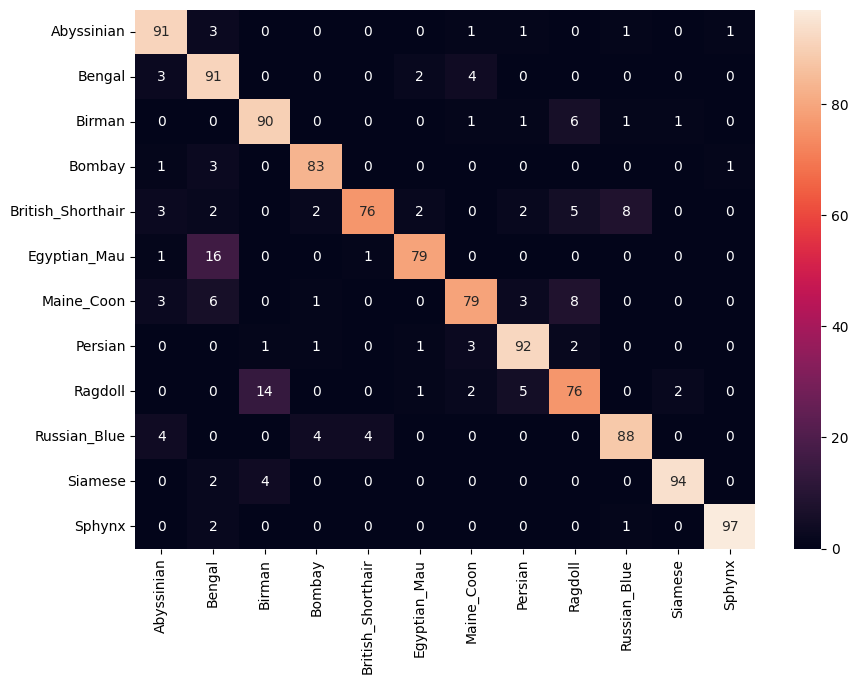


------------ FScore per class ------------


,fscore
Abyssinian,0.892157
Bengal,0.808889
Birman,0.861244
Bombay,0.927374
British_Shorthair,0.839779
Egyptian_Mau,0.868132
Maine_Coon,0.831579
Persian,0.901961
Ragdoll,0.771574
Russian_Blue,0.884422


In [ ]:
# 計算每個類別的召回率（Recall）
# `cm.diagonal()` 返回混淆矩陣的對角線元素，表示模型對每個類別的正確預測數
# `cm.sum(axis=1)` 計算每個類別的實際樣本數（每一行的總和）
recall = cm.diagonal() / cm.sum(axis=1)

# 計算每個類別的精確率（Precision）
# `cm.sum(axis=0)` 計算模型對每個類別的預測總數（每一列的總和）
precision = cm.diagonal() / cm.sum(axis=0)

# 計算每個類別的 F1 分數（FScore）
# F1 分數是精確率和召回率的調和平均數，公式為：2 * (Precision * Recall) / (Precision + Recall)
fscore = 2 * precision * recall / (precision + recall)

# 打印測試的損失值
print('loss :', loss)
# 測試損失（Loss）表示模型在測試資料上的預測誤差大小，數值越小越好

# 打印測試的準確率（Accuracy），並轉換為百分比
print('acc :', acc * 100)
# 測試準確率表示模型在測試資料上正確分類的比例，百分比形式更易理解

# 打印平均 F1 分數
print('average fscore:', np.average(fscore) * 100)
# 平均 F1 分數是所有類別的 F1 分數的平均值，衡量模型在精確率與召回率上的整體平衡表現

# 打印 Top-3 準確率
print('top3 acc :', top3_acc)
# Top-3 準確率表示模型在前三個預測中包含正確標籤的比例

# 打印分隔線與混淆矩陣標題
print('\n------------ Confusion Matrix ------------')

# 將混淆矩陣轉換為 Pandas DataFrame，以類別名稱作為索引和列名稱
df_cm = pd.DataFrame(cm, index=data['test'].class_to_idx.keys(),
                     columns=data['test'].class_to_idx.keys())

# 繪製混淆矩陣的熱圖
plt.figure(figsize=(10, 7))  # 設置圖表大小
sn.heatmap(df_cm, annot=True)  # 使用 Seaborn 繪製熱圖，顯示每個格子中的數值
plt.show()

# 打印分隔線與每個類別的 F1 分數標題
print('\n------------ FScore per class ------------')

# 將每個類別的 F1 分數轉換為 Pandas DataFrame，以類別名稱作為索引
pd.DataFrame(fscore, index=data['test'].class_to_idx.keys(), columns=['fscore'])


### Save the model
儲存模型

In [ ]:
!mkdir model
save_model_state(resnet50, 'model/resnet50-model.pth')

mkdir: cannot create directory ‘model’: File exists


## ResNet-50 with image augmentation
ResNet-50 搭配影像增強

### Build the network
建立網路

In [ ]:
# 初始化 ResNet-50 模型變數為 None，之後會將其設置為實際的模型物件
resnet50 = None

# 加載預訓練的 ResNet-50 模型，使用 torchvision 提供的模型
# pretrained=True 表示加載使用 ImageNet 訓練過的權重
resnet50 = torchvision.models.resnet50(pretrained=True)

# 凍結模型的參數，避免在訓練時修改預訓練權重
# Transfer Learning 的常見做法是僅修改最後幾層而保留原始權重
for param in resnet50.parameters():
    param.requires_grad = False  # 設定 requires_grad=False 以凍結參數

# 獲取 ResNet-50 最終全連接層（Fully Connected Layer）的輸入特徵數量
fc_inputs = resnet50.fc.in_features

# 修改 ResNet-50 的全連接層以適應新的分類問題
# 假設我們要解決的分類問題有 12 個類別
resnet50.fc = nn.Sequential(
    nn.Linear(fc_inputs, 12),   # 將輸入特徵數連接到 12 個輸出類別
    nn.LogSoftmax(dim=1)       # 使用 LogSoftmax，適合搭配 NLLLoss 損失函數
)

# 將模型移動到指定的運算設備（如 GPU 或 CPU）
# device 是預先設定好的變數，代表運算設備，例如 torch.device("cuda") 或 torch.device("cpu")
resnet50 = resnet50.to(device)

# 複製模型的初始狀態，用於後續重新訓練或恢復到初始權重
# deepcopy 可以深層複製整個模型的狀態字典，避免直接修改原始模型
init_state = copy.deepcopy(resnet50.state_dict())


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Perform grid search & cross validation
執行網格搜尋與交叉驗證

In [ ]:
# 執行網格搜尋與交叉驗證來優化模型的超參數
cv_history = grid_search_cv(
    resnet50,                      # 模型：這裡傳入我們修改過的 ResNet-50 模型
    k_fold=5,                      # 使用 5 折交叉驗證，將資料集分成 5 個子集，輪流作為訓練集和驗證集
    epochs=50,                     # 每次超參數組合訓練的最大迭代次數為 50 次
    hyperparameters={              # 定義需要搜尋的超參數範圍
        'batch_size': [32, 64],    # 搜尋批量大小（batch size）的兩個可能值：32 和 64
        'learning_rate': [1e-03, 1e-04]  # 搜尋學習率（learning rate）的兩個可能值：0.001 和 0.0001
    },
    transforms=augmented_image_transforms  # 傳入影像增強（Image Augmentation）的轉換操作，用於提升模型的泛化能力
)


串流輸出內容已截斷至最後 5000 行。
Training Batch 009 > loss: 0.6012864112854004 - acc: 0.96875
Training Batch 010 > loss: 0.6136908531188965 - acc: 0.953125
Training Batch 011 > loss: 0.6450651288032532 - acc: 0.890625
Training Batch 012 > loss: 0.613715410232544 - acc: 0.96875
Training Batch 013 > loss: 0.6123019456863403 - acc: 0.921875
Training Batch 014 > loss: 0.6070180535316467 - acc: 0.8888888955116272
Validation Batch 000 > valid_loss: 0.7018579244613647, valid_acc: 0.875
Validation Batch 001 > valid_loss: 0.6650025248527527, valid_acc: 0.90625
Validation Batch 002 > valid_loss: 0.7465490698814392, valid_acc: 0.875
Validation Batch 003 > valid_loss: 0.6368573904037476, valid_acc: 0.8260869383811951
End Epoch 24/50 > loss: 0.6299599761711924 - acc: 93.26315793238187% - valid_loss: 0.691401887340706 - valid_acc: 87.39495763257771% - Time: 2.4161s

Epoch 25/50
Training Batch 000 > loss: 0.5677506327629089 - acc: 0.9375
Training Batch 001 > loss: 0.5797770023345947 - acc: 0.921875
Training Batc

### Result of grid seach & cross validation
網格搜尋與交叉驗證的結果


---




------------ Best cross validation result ------------
{'params': {'batch_size': 64, 'learning_rate': 0.001}, 'epoch': 42, 'cv_train_acc': 0.9981060606060606, 'cv_train_loss': 0.050551024068818, 'cv_valid_acc': 0.9124579135115299, 'cv_valid_loss': 0.2576515280989685}

------------ Validation loss per epoch ------------


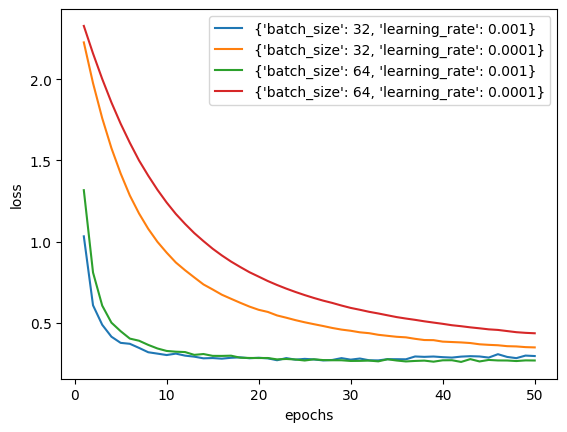

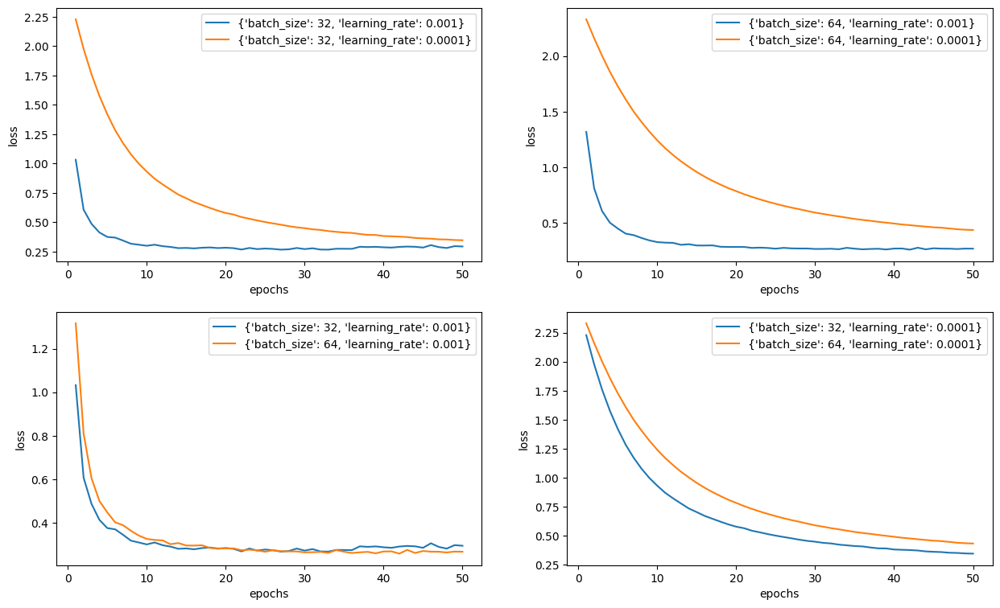


------------ Validation accuracy per epoch at ------------


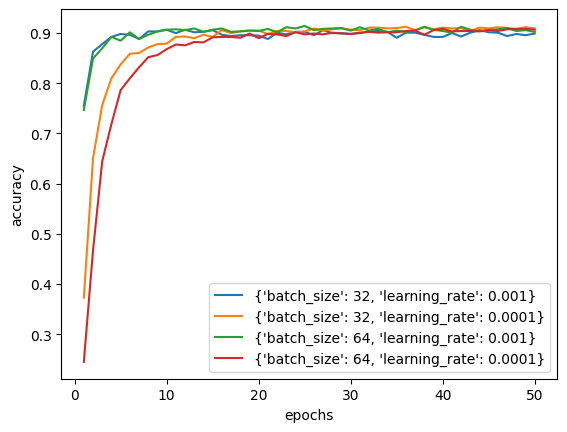

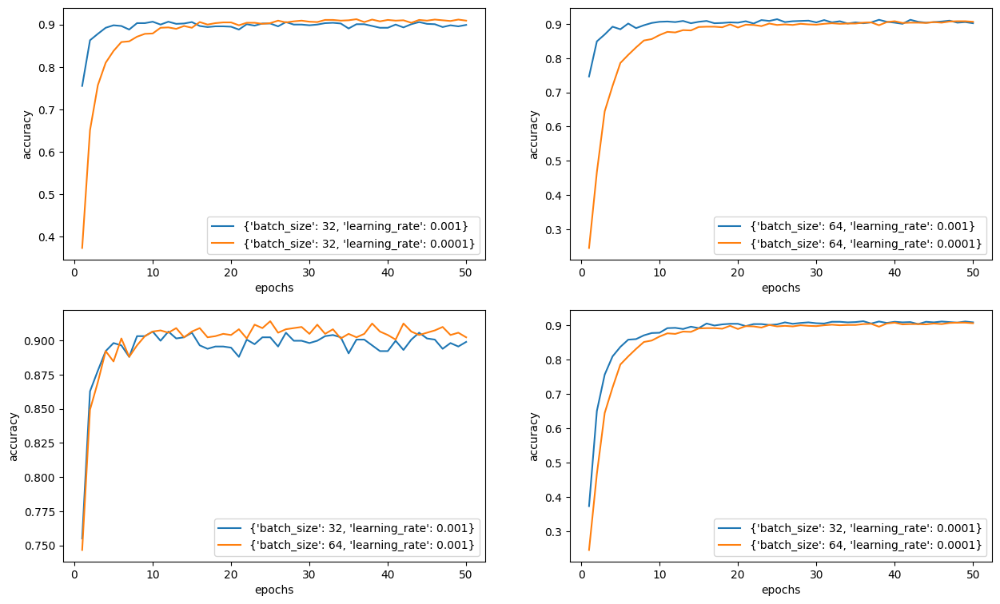

In [ ]:
# 從交叉驗證的歷史結果中提取最佳結果
# `cv_history` 是網格搜尋與交叉驗證的結果記錄，包含不同超參數組合的評估指標（如準確率、損失值等）
best_cv_result = get_best_cv_result(cv_history)

# 輸出分隔線，用於清晰展示最佳交叉驗證結果
print('\n------------ Best cross validation result ------------')

# 將最佳的交叉驗證結果輸出到終端，幫助分析最佳的超參數組合與模型效能
print(best_cv_result)

# 視覺化交叉驗證結果，繪製圖表來比較不同超參數組合的效能
# `plot_cv_result` 是一個自定義函數，用於將 `cv_history` 以圖表形式展示，例如準確率或損失值的變化
plot_cv_result(cv_history)


### Training on full training data
在完整訓練資料上進行訓練

最終模型使用最佳參數在完整的訓練資料上重新訓練。

In [ ]:
# 使用最佳超參數設定在完整訓練資料上重新訓練最終模型
# train 是自定義函數，負責模型的訓練過程
resnet50, train_history = train(
    resnet50,                          # 傳入之前修改好的 ResNet-50 模型
    best_cv_result['epoch'],           # 使用交叉驗證中找到的最佳訓練輪數（epoch），避免過度或不足訓練
    best_cv_result['params']['batch_size'],  # 使用最佳批量大小（batch size），提升訓練效率和模型效能
    best_cv_result['params']['learning_rate'],  # 使用最佳學習率（learning rate），確保模型以適當速度收斂
    init_state,                        # 傳入模型的初始狀態（深複製的狀態字典），確保重新訓練的起點一致
    transforms=augmented_image_transforms  # 傳入影像增強的轉換操作，用於提升訓練資料的多樣性和模型的泛化能力
)


Training > training data size: 1188

Epoch 1/42


Training:   0%|          | 0/19 [00:00<?, ?it/s]

End Epoch 1/42 > loss: 1.7847 - acc: 51.8519% - Time: 13.4149s

Epoch 2/42


Training:   0%|          | 0/19 [00:00<?, ?it/s]

End Epoch 2/42 > loss: 0.8212 - acc: 86.4478% - Time: 13.2395s

Epoch 3/42


...

End Epoch 40/42 > loss: 0.0616 - acc: 99.2424% - Time: 13.1365s

Epoch 41/42


Training:   0%|          | 0/19 [00:00<?, ?it/s]

End Epoch 41/42 > loss: 0.0574 - acc: 99.4108% - Time: 13.1489s

Epoch 42/42


Training:   0%|          | 0/19 [00:00<?, ?it/s]

End Epoch 42/42 > loss: 0.0604 - acc: 99.1582% - Time: 13.2522s
End Train > time: 555.8637s



### Result of training
訓練結果

loss : 0.06041882144481646
acc : 99.15824915824916


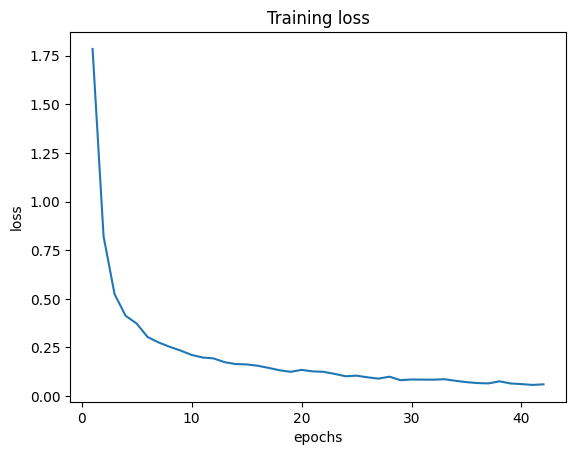

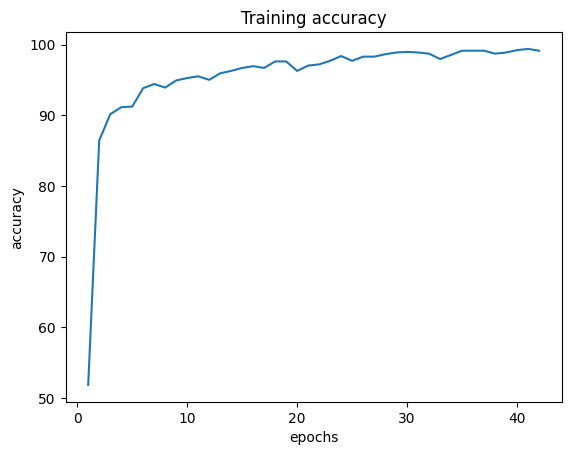

In [ ]:
# 打印訓練過程的最終損失值（loss）
# `train_history` 是訓練歷史記錄的列表，每個元素對應一個 epoch 的結果
# `train_history[-1]` 表示訓練歷史的最後一個元素（即最終 epoch 的結果）
print('loss :', train_history[-1]['avg_train_loss'])
# `avg_train_loss` 是平均訓練損失值，表示模型在訓練資料上的誤差大小

# 打印訓練過程的最終準確率（accuracy），並轉換為百分比形式
print('acc :', train_history[-1]['avg_train_acc'] * 100)
# `avg_train_acc` 是平均訓練準確率，表示模型在訓練資料上正確預測的比例

# 視覺化訓練結果
# `plot_train_result` 是一個自定義函數，用於繪製訓練損失與準確率的變化圖
# 通過圖表展示每個 epoch 的損失和準確率趨勢，有助於分析模型的訓練過程
plot_train_result(train_history)


### Testing
測試

In [ ]:
results = test(resnet50, calc_top3_acc=True)
loss = results[0]
acc = results[1]
cm = results[2]
top3_acc = results[3]

Test data size : 1183 



Testing:   0%|          | 0/37 [00:00<?, ?it/s]


Result > loss: 0.4124 - acc: 87.4049% - time: 10.8000s


Result > top3_acc: 97.8867% 



### Result of testing
測試結果

loss : 0.41236540231781293
acc : 87.4049027945566
average fscore: 87.5586887747089
top3 acc : 97.88672865595943

------------ Confusion Matrix ------------


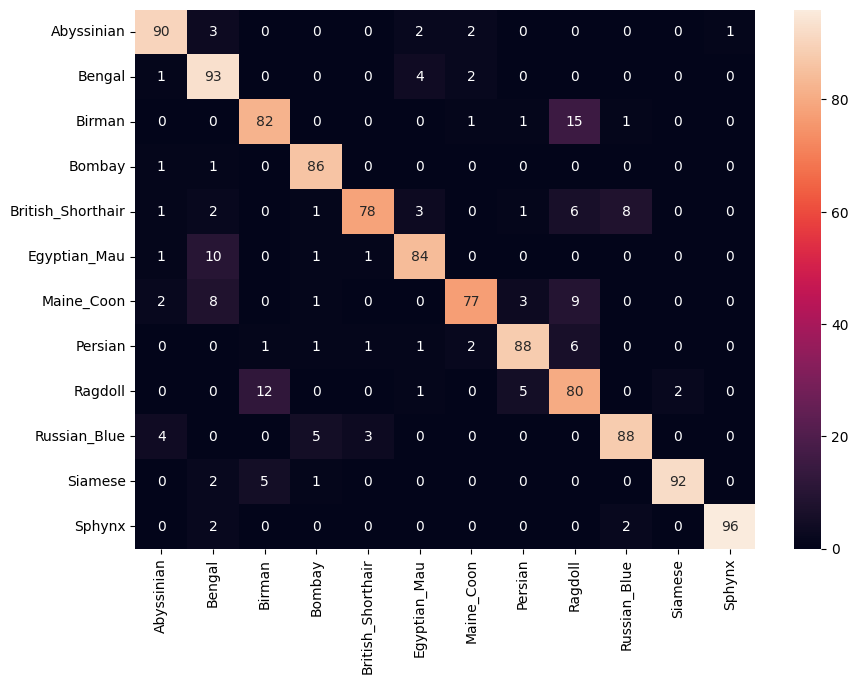


------------ FScore per class ------------


,fscore
Abyssinian,0.909091
Bengal,0.841629
Birman,0.820000
Bombay,0.934783
British_Shorthair,0.852459
Egyptian_Mau,0.875000
Maine_Coon,0.836957
Persian,0.888889
Ragdoll,0.740741
Russian_Blue,0.884422


In [ ]:
recall = cm.diagonal()/cm.sum(axis=1)
precision = cm.diagonal()/cm.sum(axis=0)
fscore = 2*precision*recall/(precision+recall)

print('loss :', loss)
print('acc :',acc*100)
print('average fscore:',np.average(fscore)*100)
print('top3 acc :',top3_acc)

print('\n------------ Confusion Matrix ------------')

df_cm = pd.DataFrame(cm, index = data['test'].class_to_idx.keys(),
                  columns = data['test'].class_to_idx.keys())
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True)
plt.show()

print('\n------------ FScore per class ------------')

pd.DataFrame(fscore,index = data['test'].class_to_idx.keys(),columns=['fscore'])

### Save the model

In [ ]:
!mkdir model
save_model_state(resnet50, 'model/resnet50-model-augmentation.pth')

mkdir: cannot create directory ‘model’: File exists


## Visualize some predictions
視覺化預測結果

\### Load the saved model for inference
載入已保存的模型進行推論

Here, the resnet50 with augmentation data will be used for the inference.
這裡將使用帶有資料增強的 ResNet-50 模型進行推論。

In [ ]:
# get the pretrained resnet50
resnet50 = torchvision.models.resnet50(pretrained=True)

# freeze model parameters
for param in resnet50.parameters():
    param.requires_grad = False

# change the final layer of ResNet50 model for transfer learning
fc_inputs = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(fc_inputs, 12),
    nn.LogSoftmax(dim=1) # For using NLLLoss()
)

# load the model state
resnet50 = load_model_state(resnet50, 'model/resnet50-model-augmentation.pth')

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-24-18cd19778f56>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detai

### Prediction function
預測函數

In [ ]:
def predict(model, img, k, actual_label):
    '''顯示影像及其模型的前 k 個預測結果'''

    predict_image = None  # 儲存預測用的影像物件

    try:
        # 檢查傳入的 img 是否是一個有效的影像物件
        img.verify()  # 如果不是有效影像，會觸發例外
        predict_image = img
    except Exception:
        # 如果不是影像物件，嘗試將 img 作為檔案路徑來打開影像
        predict_image = Image.open(img)

    # 將影像進行預處理轉換
    # `image_transforms['test']` 是預定義的轉換操作（如調整大小、標準化等）
    transform = image_transforms['test']
    predict_image_tensor = transform(predict_image)  # 將影像轉換為張量
    predict_image_tensor = predict_image_tensor.view(1, 3, 224, 224)  # 調整張量的形狀
    predict_image_tensor = predict_image_tensor.to(device)  # 將張量移到運算設備（如 GPU 或 CPU）

    # 禁用梯度計算，進行推論
    with torch.no_grad():
        model.eval()  # 將模型設為推論模式，禁用 dropout 和 batch normalization 的隨機性
        out = model(predict_image_tensor)  # 將影像張量傳入模型，獲得輸出
        ps = torch.exp(out)  # 將模型的輸出（log probability）轉換為機率值

        # 獲取前 k 個最高的預測機率及其對應的類別
        topprob, topclass = ps.topk(k, dim=1)  # `topk` 返回前 k 個最大值及其索引
        topprob_np = topprob.cpu().numpy()[0]  # 將機率值移到 CPU 並轉換為 NumPy 陣列
        topclass_np = topclass.cpu().numpy()[0]  # 將類別索引移到 CPU 並轉換為 NumPy 陣列

        # 輸出實際標籤和模型的前 k 個預測結果
        print('Actual :')  # 輸出實際標籤
        print('-', actual_label, '\n')  # 顯示傳入的實際類別標籤
        print('Top', k, 'prediction :')  # 輸出前 k 個預測
        for idx, prob in enumerate(topprob_np):  # 遍歷每個預測結果
            print('-', idx_to_class[topclass_np[idx]], ':', prob * 100)
            # 將類別索引轉換為實際類別名稱並顯示對應機率百分比

        # 顯示原始影像，方便直觀查看模型的預測結果
        plt.figure()  # 建立一個新的圖表
        plt.imshow(predict_image)  # 顯示影像
        plt.show()  # 顯示圖表

        print('------------------------------------------------------')  # 分隔線方便閱讀


視覺化每個品種的正確預測結果### Visualize a correct prediction for each breed

Actual :
- Abyssinian 

Top 3 prediction :
- Abyssinian : 99.98711347579956
- Russian_Blue : 0.005829733345308341
- Bengal : 0.003672796083264984


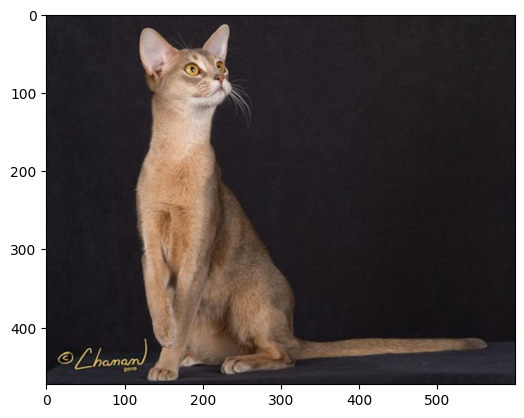

------------------------------------------------------
Actual :
- Bengal 

Top 3 prediction :
- Bengal : 95.11576890945435
- Egyptian_Mau : 3.6842849105596542
- Maine_Coon : 0.6655949167907238


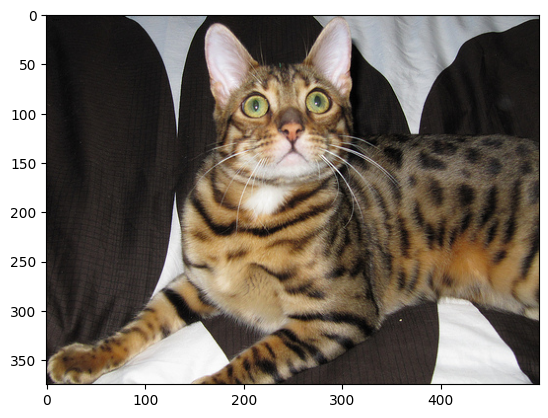

------------------------------------------------------
Actual :
- Birman 

Top 3 prediction :
- Birman : 96.32769823074341
- Ragdoll : 3.623707592487335
- Siamese : 0.022634769266005605


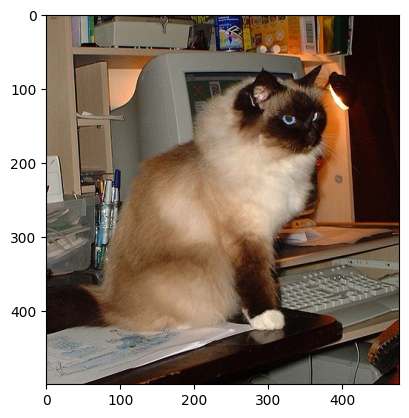

------------------------------------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 95.56363821029663
- Russian_Blue : 3.350096195936203
- British_Shorthair : 0.6740700919181108


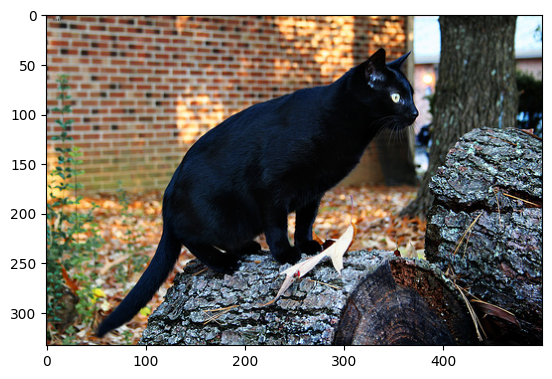

------------------------------------------------------
Actual :
- British_Shorthair 

Top 3 prediction :
- British_Shorthair : 88.33578824996948
- Russian_Blue : 11.567331105470657
- Egyptian_Mau : 0.03151274868287146


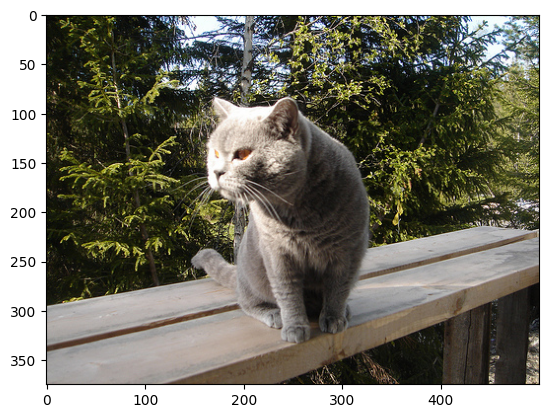

------------------------------------------------------
Actual :
- Egyptian_Mau 

Top 3 prediction :
- Egyptian_Mau : 99.9932050704956
- Bengal : 0.003335856308694929
- Russian_Blue : 0.0016963193047558889


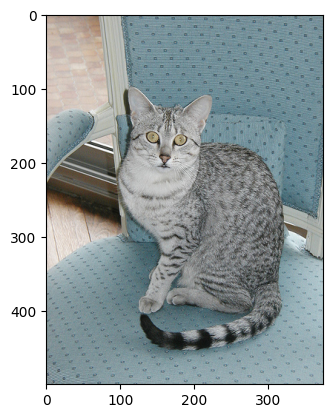

------------------------------------------------------
Actual :
- Maine_Coon 

Top 3 prediction :
- Maine_Coon : 99.54579472541809
- Persian : 0.36634227726608515
- Ragdoll : 0.039230872062034905


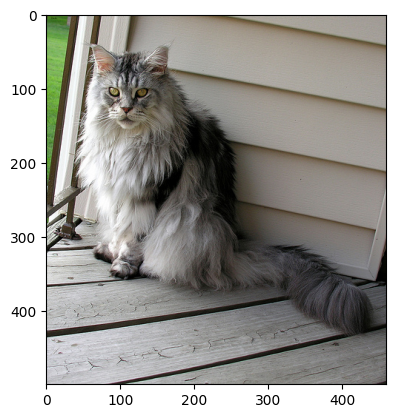

------------------------------------------------------
Actual :
- Persian 

Top 3 prediction :
- Persian : 99.92018342018127
- Maine_Coon : 0.028353396919555962
- British_Shorthair : 0.02325885434402153


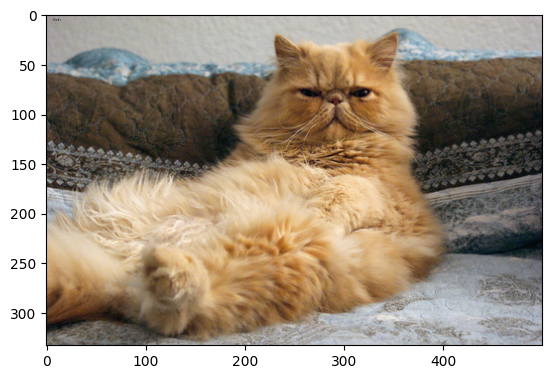

------------------------------------------------------
Actual :
- Ragdoll 

Top 3 prediction :
- Ragdoll : 99.28421974182129
- Birman : 0.6295857019722462
- Maine_Coon : 0.08018900989554822


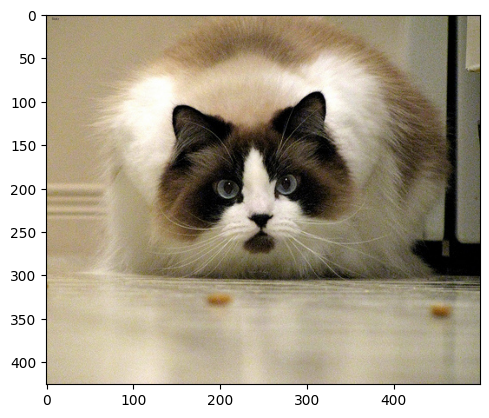

------------------------------------------------------
Actual :
- Russian_Blue 

Top 3 prediction :
- Russian_Blue : 97.67407178878784
- British_Shorthair : 1.477134134620428
- Egyptian_Mau : 0.5508981645107269


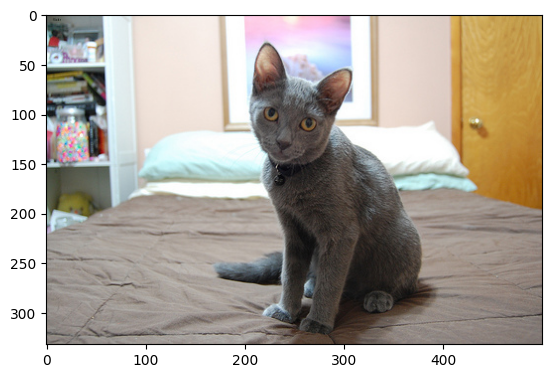

------------------------------------------------------
Actual :
- Siamese 

Top 3 prediction :
- Siamese : 94.668710231781
- Birman : 5.181170254945755
- Ragdoll : 0.14179559657350183


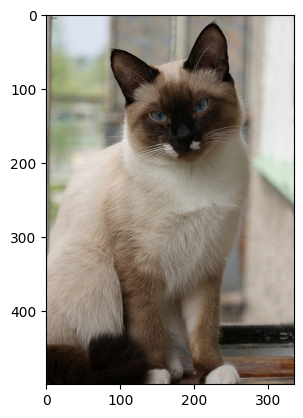

------------------------------------------------------
Actual :
- Sphynx 

Top 3 prediction :
- Sphynx : 99.99393224716187
- Egyptian_Mau : 0.0034910997783299536
- Persian : 0.0008326663191837724


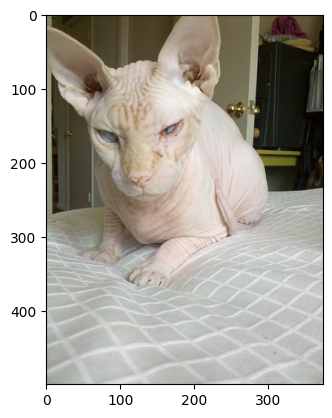

------------------------------------------------------


In [ ]:
# 視覺化每個品種的正確預測結果
# 使用 predict 函數對每張測試影像進行預測，並顯示結果

predict(resnet50, 'data/test/Abyssinian/Abyssinian_2.jpg', k=3, actual_label='Abyssinian')
# 預測 Abyssinian 品種的影像
# `k=3` 表示顯示模型的前三個預測類別及其機率
# `actual_label='Abyssinian'` 是實際類別標籤，用於與模型預測結果進行比較

predict(resnet50, 'data/test/Bengal/Bengal_46.jpg', k=3, actual_label='Bengal')
# 預測 Bengal 品種的影像

predict(resnet50, 'data/test/Birman/Birman_29.jpg', k=3, actual_label='Birman')
# 預測 Birman 品種的影像

predict(resnet50, 'data/test/Bombay/Bombay_47.jpg', k=3, actual_label='Bombay')
# 預測 Bombay 品種的影像

predict(resnet50, 'data/test/British_Shorthair/British_Shorthair_37.jpg', k=3, actual_label='British_Shorthair')
# 預測 British_Shorthair 品種的影像

predict(resnet50, 'data/test/Egyptian_Mau/Egyptian_Mau_62.jpg', k=3, actual_label='Egyptian_Mau')
# 預測 Egyptian_Mau 品種的影像

predict(resnet50, 'data/test/Maine_Coon/Maine_Coon_52.jpg', k=3, actual_label='Maine_Coon')
# 預測 Maine_Coon 品種的影像

predict(resnet50, 'data/test/Persian/Persian_63.jpg', k=3, actual_label='Persian')
# 預測 Persian 品種的影像

predict(resnet50, 'data/test/Ragdoll/Ragdoll_205.jpg', k=3, actual_label='Ragdoll')
# 預測 Ragdoll 品種的影像

predict(resnet50, 'data/test/Russian_Blue/Russian_Blue_57.jpg', k=3, actual_label='Russian_Blue')
# 預測 Russian_Blue 品種的影像

predict(resnet50, 'data/test/Siamese/Siamese_78.jpg', k=3, actual_label='Siamese')
# 預測 Siamese 品種的影像

predict(resnet50, 'data/test/Sphynx/Sphynx_95.jpg', k=3, actual_label='Sphynx')
# 預測 Sphynx 品種的影像


### Visualize the misclassified predictions
視覺化錯誤分類的預測結果

#### Top 3 misclassified predictions
前 3 個錯誤分類的預測結果

In [ ]:
# 建立一個從類別索引到類別名稱的映射字典
# `data['test'].class_to_idx` 是資料集的類別與索引對應關係
# `idx_to_class` 將其反轉，方便使用索引查找對應的類別名稱
idx_to_class = {val: key for key, val in data['test'].class_to_idx.items()}

# 初始化一個列表，用於儲存錯誤分類的記錄
misclass = []

# 遍歷混淆矩陣（cm），找出所有錯誤分類的記錄
# 混淆矩陣 cm 的結構是：行表示實際類別，列表示預測類別
for i in range(len(cm)):  # 遍歷每個實際類別
    for j in range(len(cm[i])):  # 遍歷每個預測類別
        if i != j:  # 如果實際類別和預測類別不同，表示錯誤分類
            # 添加錯誤分類的記錄到 misclass 列表
            misclass.append([idx_to_class[i], idx_to_class[j], cm[i][j]])
            # `idx_to_class[i]` 是實際類別名稱
            # `idx_to_class[j]` 是預測類別名稱
            # `cm[i][j]` 是錯誤分類的數量（從混淆矩陣中獲得）

# 將錯誤分類的記錄轉換為 Pandas DataFrame，方便後續分析
df_misclass = pd.DataFrame(
    misclass,  # 錯誤分類的數據列表
    columns=['actual', 'prediction', 'count']  # 設定欄位名稱
)

# 根據錯誤分類的數量（count）進行排序，從大到小排列
df_misclass = df_misclass.sort_values(by=['count'], ascending=False)

# 顯示錯誤分類數量最多的前三個記錄
df_misclass.head(3)


,actual,prediction,count
29,Birman,Ragdoll,15
90,Ragdoll,Birman,12
56,Egyptian_Mau,Bengal,10


#### Visualize the top 3 misclassified predictions
視覺化前 3 個錯誤分類的預測結果

Here, we want to see the top misclassied images, such as Ragdoll predicted as Birman, British Shorthair predicted as Russian Blue, Egyptian Mau predicted as Bengal, and vice versa.
在這裡，我們希望看到錯誤分類數量最多的影像，例如將 Ragdoll 預測為 Birman、將 British Shorthair 預測為 Russian Blue、將 Egyptian Mau 預測為 Bengal，反之亦然。

Actual :
- Birman 

Top 3 prediction :
- Ragdoll : 77.56370902061462
- Birman : 17.561012506484985
- Persian : 4.236149415373802


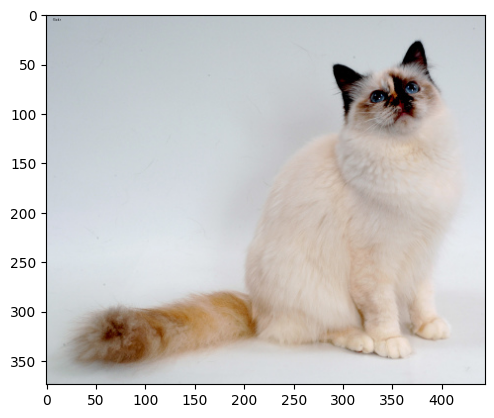

------------------------------------------------------
Actual :
- Ragdoll 

Top 3 prediction :
- Birman : 97.88063764572144
- Siamese : 1.2778392061591148
- Ragdoll : 0.7058106828480959


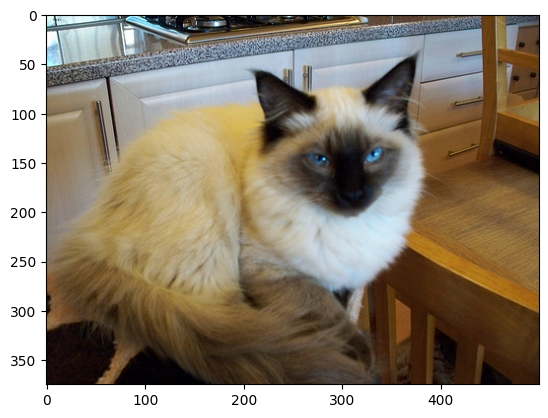

------------------------------------------------------
Actual :
- British_Shorthair 

Top 3 prediction :
- British_Shorthair : 59.180885553359985
- Russian_Blue : 39.15320932865143
- Persian : 1.2402002699673176


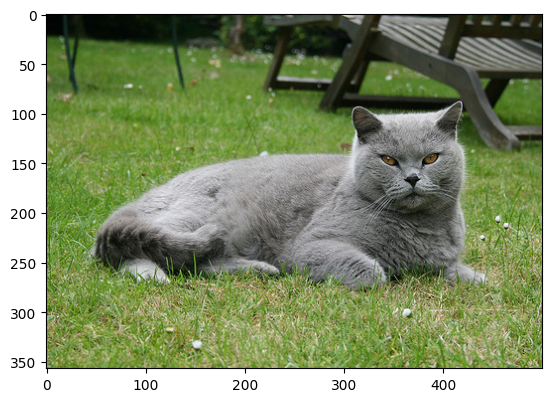

------------------------------------------------------
Actual :
- Russian_Blue 

Top 3 prediction :
- British_Shorthair : 66.31864905357361
- Russian_Blue : 27.27532386779785
- Siamese : 3.6892499774694443


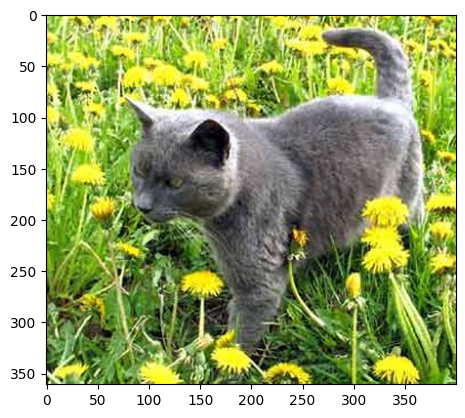

------------------------------------------------------
Actual :
- Egyptian_Mau 

Top 3 prediction :
- Bengal : 69.052654504776
- Egyptian_Mau : 30.610927939414978
- Abyssinian : 0.17869495786726475


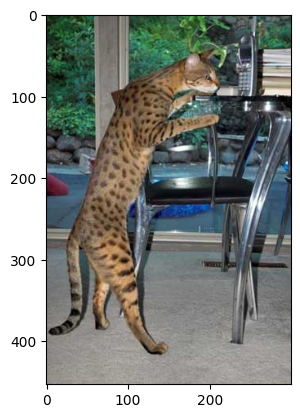

------------------------------------------------------
Actual :
- Bengal 

Top 3 prediction :
- Egyptian_Mau : 98.03712368011475
- Bengal : 1.956360787153244
- Maine_Coon : 0.0027017473257728852


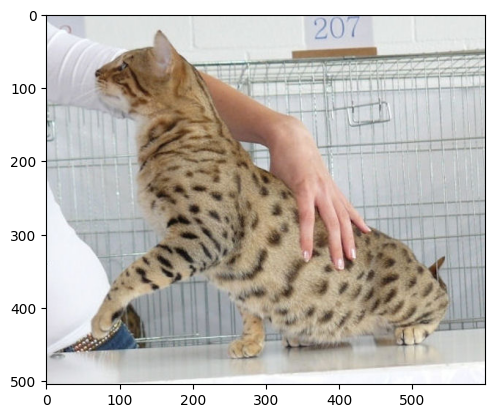

------------------------------------------------------


In [ ]:
predict(resnet50, 'data/test/Birman/Birman_99.jpg', k=3, actual_label='Birman')
predict(resnet50, 'data/test/Ragdoll/Ragdoll_35.jpg', k=3, actual_label='Ragdoll')
predict(resnet50, 'data/test/British_Shorthair/British_Shorthair_28.jpg', k=3, actual_label='British_Shorthair')
predict(resnet50, 'data/test/Russian_Blue/Russian_Blue_264.jpg', k=3, actual_label='Russian_Blue')
predict(resnet50, 'data/test/Egyptian_Mau/Egyptian_Mau_85.jpg', k=3, actual_label='Egyptian_Mau')
predict(resnet50, 'data/test/Bengal/Bengal_2.jpg', k=3, actual_label='Bengal')

In [ ]:
### Predicting transformed images

Here, we will try to transform an image which was correctly classfied, and try to predict the transformed images.
在這裡，我們將對一張被正確分類的影像進行轉換，並嘗試預測轉換後的影像。

-----------------------Original-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 95.56363821029663
- Russian_Blue : 3.350096195936203
- British_Shorthair : 0.6740700919181108


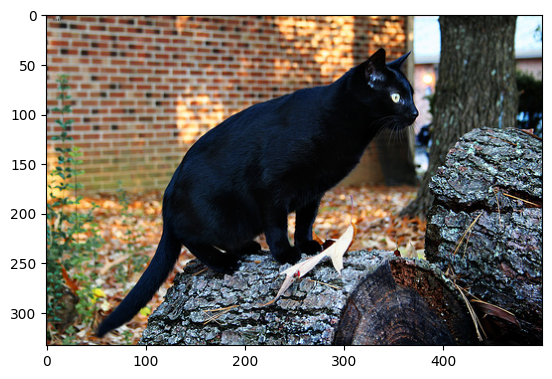

------------------------------------------------------
------------------Horizontal Flip-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 94.7200059890747
- Russian_Blue : 4.400711506605148
- Siamese : 0.3453024663031101


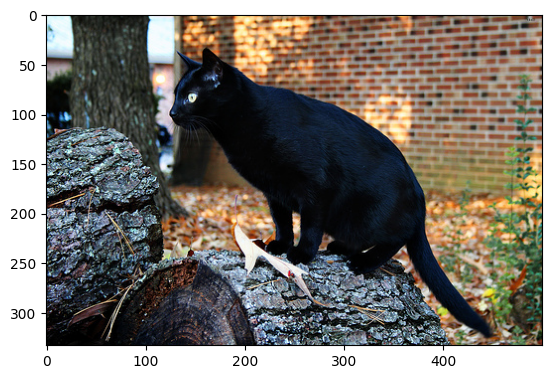

------------------------------------------------------
------------------Vertical Flip-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Sphynx : 35.62217950820923
- Bombay : 34.799909591674805
- Bengal : 18.789765238761902


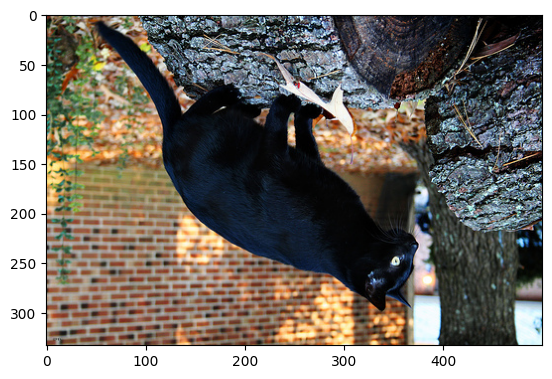

------------------------------------------------------
------------------Darker-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 89.62615728378296
- Russian_Blue : 8.221979439258575
- Sphynx : 0.5484095774590969


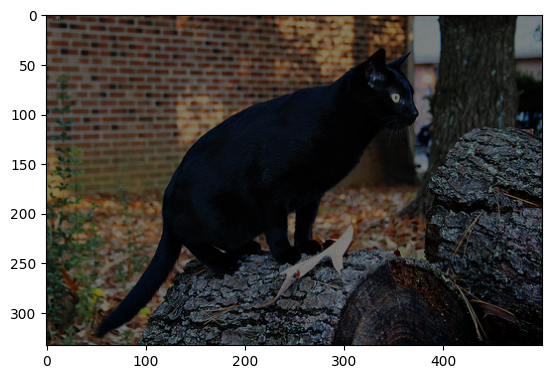

------------------------------------------------------
------------------Brighter-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 84.70670580863953
- Russian_Blue : 13.246262073516846
- British_Shorthair : 1.670750044286251


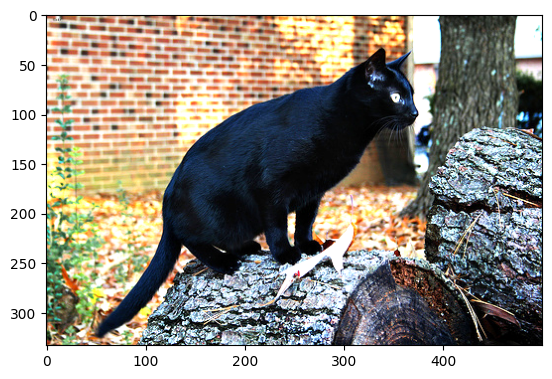

------------------------------------------------------
------------------Lower Contrast-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 68.38237643241882
- Russian_Blue : 26.008567214012146
- Siamese : 1.6062522307038307


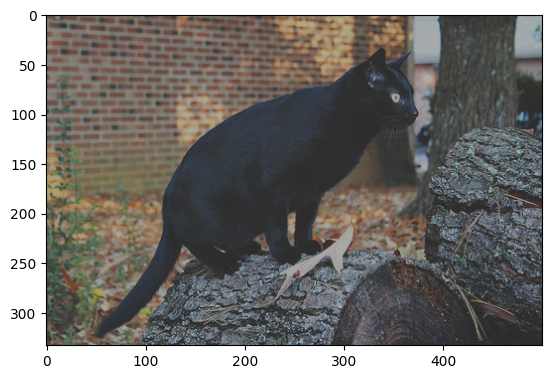

------------------------------------------------------
------------------Higher Contrast-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 70.09553909301758
- Sphynx : 14.46334719657898
- British_Shorthair : 5.315640568733215


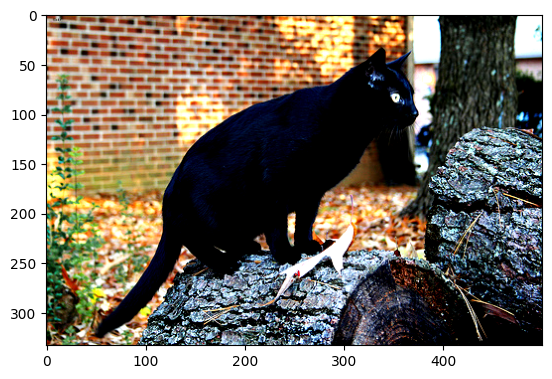

------------------------------------------------------
------------------Add Noise-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 60.19523739814758
- Russian_Blue : 19.70481425523758
- Sphynx : 9.902459383010864


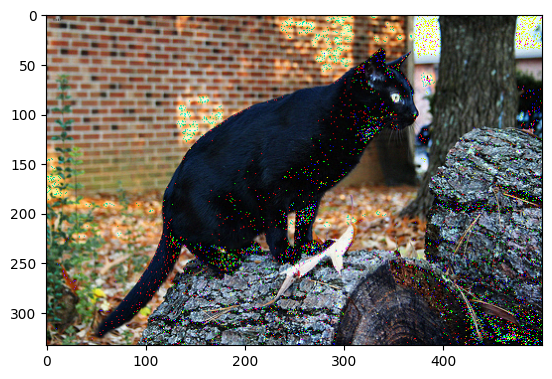

------------------------------------------------------
------------------Rotate-------------------------
Actual :
- Bombay 

Top 3 prediction :
- Bombay : 86.8631362915039
- Russian_Blue : 12.040933221578598
- British_Shorthair : 0.4740683827549219


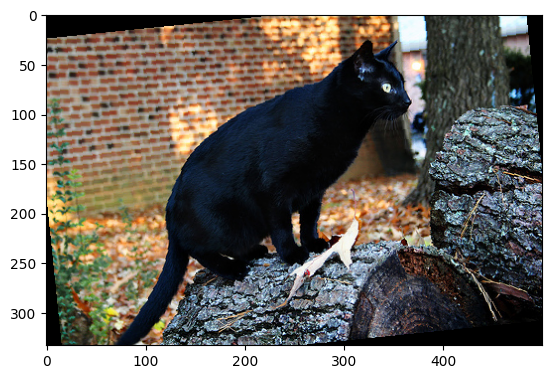

------------------------------------------------------
------------------All Transforms -------------------------
Actual :
- Bombay 

Top 3 prediction :
- Sphynx : 48.56182336807251
- Bombay : 23.84859323501587
- Abyssinian : 9.556790441274643


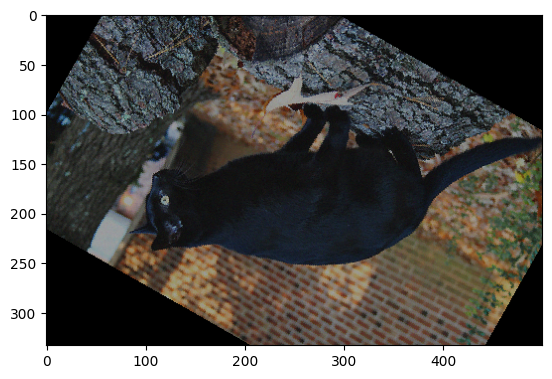

------------------------------------------------------


In [ ]:
# 定義影像轉換的工具與操作

# 將張量轉換為 PIL 影像，便於可視化
to_pil = transforms.ToPILImage()

# 將 PIL 影像轉換為張量，便於模型處理
to_tensor = transforms.ToTensor()

# 定義隨機水平翻轉（100% 機率翻轉）
horizontal_flip = transforms.RandomHorizontalFlip(p=1)

# 定義隨機垂直翻轉（100% 機率翻轉）
vertical_flip = transforms.RandomVerticalFlip(p=1)

# 定義降低亮度（暗化影像）
darken = transforms.ColorJitter(brightness=(0.5, 0.5))  # 亮度減半

# 定義增加亮度（亮化影像）
brighten = transforms.ColorJitter(brightness=(1.5, 1.5))  # 亮度增加 1.5 倍

# 定義降低對比度
dec_contrast = transforms.ColorJitter(contrast=(0.5, 0.5))  # 對比度減半

# 定義增加對比度
inc_contrast = transforms.ColorJitter(contrast=(1.5, 1.5))  # 對比度增加 1.5 倍

# 定義加入隨機噪聲
noise = transforms.Lambda(lambda x: x + torch.randn_like(x) * 0.01)  # 加入 0.01 強度的隨機噪聲

# 定義旋轉影像，隨機旋轉角度範圍為 ±30 度
rotate = transforms.RandomRotation(30)

# 讀取原始影像（Bombay 貓的測試影像）
ori_img = Image.open('data/test/Bombay/Bombay_47.jpg')

# 應用不同的影像轉換操作
h_flip_img = horizontal_flip(ori_img)  # 水平翻轉
v_flip_img = vertical_flip(ori_img)  # 垂直翻轉
dark_img = darken(ori_img)  # 降低亮度
bright_img = brighten(ori_img)  # 增加亮度
dec_con_img = dec_contrast(ori_img)  # 降低對比度
inc_con_img = inc_contrast(ori_img)  # 增加對比度
noise_img = to_pil(noise(to_tensor(ori_img)))  # 加入隨機噪聲並轉換回 PIL 影像
rotated_img = rotate(ori_img)  # 旋轉影像

# 應用所有轉換操作，依次組合
all_transforms_img = vertical_flip(horizontal_flip(ori_img))  # 水平 + 垂直翻轉
all_transforms_img = brighten(darken(all_transforms_img))  # 增亮 + 降亮
all_transforms_img = inc_contrast(dec_contrast(all_transforms_img))  # 增對比 + 降對比
all_transforms_img = to_pil(noise(to_tensor(all_transforms_img)))  # 加入噪聲
all_transforms_img = rotate(all_transforms_img)  # 旋轉影像

# 原始影像的預測結果
print('-----------------------Original-------------------------')
predict(resnet50, 'data/test/Bombay/Bombay_47.jpg', k=3, actual_label='Bombay')

# 水平翻轉後的預測結果
print('------------------Horizontal Flip-------------------------')
predict(resnet50, h_flip_img, k=3, actual_label='Bombay')

# 垂直翻轉後的預測結果
print('------------------Vertical Flip-------------------------')
predict(resnet50, v_flip_img, k=3, actual_label='Bombay')

# 降低亮度後的預測結果
print('------------------Darker-------------------------')
predict(resnet50, dark_img, k=3, actual_label='Bombay')

# 增加亮度後的預測結果
print('------------------Brighter-------------------------')
predict(resnet50, bright_img, k=3, actual_label='Bombay')

# 降低對比度後的預測結果
print('------------------Lower Contrast-------------------------')
predict(resnet50, dec_con_img, k=3, actual_label='Bombay')

# 增加對比度後的預測結果
print('------------------Higher Contrast-------------------------')
predict(resnet50, inc_con_img, k=3, actual_label='Bombay')

# 加入隨機噪聲後的預測結果
print('------------------Add Noise-------------------------')
predict(resnet50, noise_img, k=3, actual_label='Bombay')

# 旋轉影像後的預測結果
print('------------------Rotate-------------------------')
predict(resnet50, rotated_img, k=3, actual_label='Bombay')

# 應用所有轉換後的預測結果
print('------------------All Transforms -------------------------')
predict(resnet50, all_transforms_img, k=3, actual_label='Bombay')


In [ ]:
!pip install torchvision matplotlib


In [ ]:
from google.colab import drive
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# 掛載 Google 雲端硬碟
drive.mount('/content/drive')

# 設置設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加載 ResNet-50 模型
resnet50 = models.resnet50(pretrained=False)
num_classes = 12  # 替換為您的類別數量
resnet50.fc = nn.Sequential(
    nn.Linear(resnet50.fc.in_features, num_classes),
    nn.LogSoftmax(dim=1)
)
resnet50 = resnet50.to(device)
resnet50.load_state_dict(torch.load('/content/drive/MyDrive/Colab/cat_breed_classification/model/resnet50-model-augmentation.pth', map_location=device))
resnet50.eval()

# 定義類別名稱
class_names = ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair',
               'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue',
               'Siamese', 'Sphynx']

# 定義資料轉換
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 預測函數
def predict_uploaded_image(model, image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = data_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
        top1_prob, top1_class = torch.max(probabilities, 0)

    # 判斷是否低於 60%，若低於則顯示 "MIX"
    if top1_prob.item() * 100 < 0:
        print("預測類別: 米克斯貓 (混種貓)")
        plt.imshow(image)
        plt.title("預測: MIX")
    else:
        print(f"預測類別: {class_names[top1_class]} (機率: {top1_prob.item() * 100:.2f}%)")
        plt.imshow(image)
        plt.title(f"預測: {class_names[top1_class]} ({top1_prob.item() * 100:.2f}%)")

    plt.axis('off')
    plt.show()



# 上傳圖片並進行推論
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
predict_uploaded_image(resnet50, image_path)


Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
